In [1]:
import numpy as np
import random
from multiprocessing import Pool
import pandas as pd
from scipy.interpolate import interp1d
from scipy.special import gamma, erf
import scipy.stats as stats
from scipy.stats import binom

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
font_manager.fontManager.addfont('/home/vvelan/DarkLim/examples/styles/Times_New_Roman.ttf')

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.style.use('/home/vvelan/DarkLim/examples/styles/Style.mplstyle')

import sys
sys.path.insert(0, 'ExistingLimits/')
import MichaelLimits as ML

import darklim
sys.path.insert(0, '/home/vvelan/DarkELF/')
import darkelf

import qetpy
import detprocess
import h5py
import time
import pickle
import glob

%matplotlib inline


In [2]:
def run57_lee_bkgd(scale_by=1.0):
    fin = 'Run57_LEE_templates/combined_spectra_shared57_CRESST_extrap.txt'
    template = np.loadtxt(fin,skiprows=1)
    interp_func = interp1d(template[:,0],template[:,1],
                            bounds_error=False,
                            #fill_value='extrapolate',
                            fill_value=0.,
                            assume_sorted=True)

    return lambda x: (interp_func(x) / 86400. * scale_by)


In [3]:
def extrapolate(data, mass=1e6):
    m0, s0 = data[-1]
    return np.concatenate([data,[[mass, s0*mass/m0]]], axis=0)

def minbound(curves, masses=None):
    if masses is None:
        masses = np.logspace(-3, 4, 200)
    result = np.array([np.nan]*len(masses))
    for curve in curves:
        if curve[-1][0] < masses[-1]:
            curve = extrapolate(curve, masses[-1])
        yinterp = 10**(interp1d(*(np.log10(curve).T), bounds_error=False)(np.log10(masses)))
        #yinterp = interp1d(*(curve.T), bounds_error=False)(masses)
        result = np.nanmin([result, yinterp], axis=0)
    return np.array([masses, result]).T

def log_interp(zz, xx, yy, left=None, right=None):
    logz = np.log(zz)
    logx = np.log(xx)
    logy = np.log(yy)
    return np.exp(np.interp(logz, logx, logy, left=left, right=right))

def load_and_plot_existing(leg=True, lw=1, leg_params={}, ER_model='massless', cosmic=False, migdal=False, direct=False):
    
    curves_dir = 'ExistingLimits/'
    handles = []
    fig, ax = plt.subplots(1, 1, figsize=(10,7.5))
    ax.set_xscale('log')
    ax.set_yscale('log')
    mpl.rcParams['font.size'] = 14
    
    if ER_model == 'massive':

        m_lim, x_lim = np.loadtxt(curves_dir + 'DAMIC_LBC_ER_Massive_2025.txt').transpose()
        l, = ax.plot(m_lim*1e3, x_lim, '--', color='magenta', lw=lw, label='LBC (DAMIC) 2025')
        handles.append(l)
        ax.fill_between(m_lim*1e3, x_lim, 1e-22, facecolor='whitesmoke')
        
        m_lim_1, x_lim_1 = np.loadtxt(curves_dir + 'DAMIC_ER_Massive_2023.txt').transpose()
        m_lim_2, x_lim_2 = np.loadtxt(curves_dir + 'DAMIC_ER_Massive_2024.txt').transpose()
        m_lim = np.geomspace(min(m_lim_1[0], m_lim_2[0]), max(m_lim_1[-1], m_lim_2[-1]), 150)
        x_lim_1_adj = log_interp(m_lim, m_lim_1, x_lim_1, left=np.inf, right=np.inf)
        x_lim_2_adj = log_interp(m_lim, m_lim_2, x_lim_2, left=np.inf, right=np.inf)
        x_lim = np.minimum(x_lim_1_adj, x_lim_2_adj)
        l, = ax.plot(m_lim, x_lim, '--', color='#CFC0E5', lw=lw, label='DAMIC 2023, 2024')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-22, facecolor='whitesmoke')
        
        m_lim, x_lim = np.loadtxt(curves_dir + 'Darkside50_ER_Massive_2023.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#CE977A', lw=lw, label='Darkside-50 2023')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-22, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'SENSEI_SNOLAB_ER_Massive.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#a4dbed', lw=lw, label='SENSEI 2025')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-22, facecolor='whitesmoke')
        
        m_lim, x_lim = np.loadtxt(curves_dir + 'PandaX4T_ER_Massive_2023.txt').transpose()
        l, = ax.plot(m_lim*1e3, x_lim, '--', color='#CA778C', lw=lw, label='PandaX-4T 2023')
        handles.append(l)
        ax.fill_between(m_lim*1e3, x_lim, 1e-22, facecolor='whitesmoke')
        
        m_lim, x_lim = np.loadtxt(curves_dir + 'Freeze_out_Scalar_ER_Massive.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '-', color='orange', lw=lw*2, label='Freeze-out Scalar')
        handles.append(l)

        #m_lim, x_lim = np.loadtxt(curves_dir + 'XENON1T_S2Only_Solar_Reflected_ER_Massive.txt').transpose()
        #ax.plot(m_lim, x_lim, '--', lw=1.5, label='XENON1T S2only (Solar Refl.)')
        #m_lim, x_lim = np.loadtxt(curves_dir + 'SENSEI_SNOLAB_Solar_Reflection_ER_Massive.txt').transpose()
        #ax.plot(m_lim, x_lim, '--', lw=1.5, label='SENSEI SNOLAB (Solar Refl.)')

        if leg:
            leg1 = ax.legend(handles=handles, **leg_params)
            ax.add_artist(leg1)

    elif ER_model == 'massless':
        
        m_lim, x_lim = np.loadtxt(curves_dir + 'DAMIC_LBC_ER_Massless_2025.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='magenta', lw=lw, label='LBC (DAMIC) 2025', alpha=0.5)
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-22, facecolor='whitesmoke')

        m_lim_1, x_lim_1 = np.loadtxt(curves_dir + 'DAMIC_ER_Massless_2023.txt').transpose()
        m_lim_2, x_lim_2 = np.loadtxt(curves_dir + 'DAMIC_ER_Massless_2024.txt').transpose()
        m_lim = np.geomspace(min(m_lim_1[0], m_lim_2[0]), max(m_lim_1[-1], m_lim_2[-1]), 150)
        x_lim_1_adj = log_interp(m_lim, m_lim_1, x_lim_1, left=np.inf, right=np.inf)
        x_lim_2_adj = log_interp(m_lim, m_lim_2, x_lim_2, left=np.inf, right=np.inf)
        x_lim = np.minimum(x_lim_1_adj, x_lim_2_adj)
        l, = ax.plot(m_lim, x_lim, '--', color='#CFC0E5', lw=lw, label='DAMIC 2023, 2024')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-22, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'SENSEI_SNOLAB_ER_Massless.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#a4dbed', lw=lw, label='SENSEI 2025')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-22, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'Freeze_in_ER_Massless.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '-', color='#FF9039', lw=lw*2, label='Freeze-in')
        handles.append(l)

        if leg:
            leg1 = ax.legend(handles=handles, **leg_params)
            ax.add_artist(leg1)

    elif ER_model == 'absorption':

        m_lim, x_lim = np.loadtxt(curves_dir + 'DAMIC_Absorption_2025.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='magenta', lw=lw, label='LBC (DAMIC) 2025')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e0, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'SENSEI_Absorption_2025.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#CFC0E5', lw=lw, label='SENSEI 2025')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e0, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'XENON1T_Absorption_2019.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#a4dbed', lw=lw, label='XENON1T 2019')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e0, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'XENONnT_Absorption_2022.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '-', color='#FF9039', lw=lw*2, label='XENONnT 2022')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e0, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'XENONnT_Absorption_2024_Lower.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#CA778C', lw=lw, label='XENONnT 2024')
        handles.append(l)

        m_lim, x_lim = np.loadtxt(curves_dir + 'XENONnT_Absorption_2024_Upper.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#CA778C', lw=lw)
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e0, facecolor='whitesmoke')

        if leg:
            leg1 = ax.legend(handles=handles, **leg_params)
            ax.add_artist(leg1)

    else:

        if cosmic:

            m_lim = ML.Data_Cosmic_ray[:,0]
            x_lim = ML.Data_Cosmic_ray[:,1]
            ax.plot(m_lim, x_lim, linewidth=0.5, color='gray', linestyle='-.', label="Cosmic ray scattered DM")
            ax.fill_between(m_lim, np.ones_like(x_lim)*1e-22, x_lim, color='whitesmoke')

            m_lim = ML.Data_Milky_way_satellites_2021[:,0]
            x_lim = ML.Data_Milky_way_satellites_2021[:,1]
            ax.plot(m_lim, x_lim, linewidth=0.5, color='gray', linestyle='--', label="Milky Way satellites")
            ax.fill_between(m_lim, np.ones_like(x_lim)*1e-22, x_lim, color='whitesmoke')

            m_lim = ML.Data_Ly_alpha_2022[:,0]
            x_lim = ML.Data_Ly_alpha_2022[:,1]
            ax.plot(m_lim, x_lim, linewidth=0.5, color='gray', linestyle=':', label="Ly-alpha forest")
            ax.fill_between(m_lim, np.ones_like(x_lim)*1e-22, x_lim, color='whitesmoke')
            
            m_lim = ML.Data_CMB[:,0]
            x_lim = ML.Data_CMB[:,1]
            ax.plot(m_lim, x_lim, linewidth=0.5, color='gray', linestyle='-', label="CMB")
            ax.fill_between(m_lim, np.ones_like(x_lim)*1e-22, x_lim, color='whitesmoke')
            
        if migdal:
            
            m_lim, x_lim = np.loadtxt(curves_dir + 'DAMIC_LBC_Migdal_2025.txt').transpose()
            l, = ax.plot(m_lim*1e3, x_lim, lw=lw, color='#CFC0E5', linestyle='--', label='LBC (DAMIC) Migdal 2025')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-22, facecolor='#ad8150', alpha=0.1)
            
            m_lim, x_lim = np.loadtxt(curves_dir + 'SENSEI_Migdal_NR.txt').transpose()
            l, = ax.plot(m_lim, x_lim, lw=lw, color='#CE977A', linestyle='--', label='SENSEI Migdal NR')
            handles.append(l)
            ax.fill_between(m_lim, x_lim, 1e-22, facecolor='#ad8150', alpha=0.1)
            
            m_lim, x_lim = np.loadtxt(curves_dir + 'Darkside50_Migdal_2023.txt').transpose()
            l, ax.plot(m_lim*1e3, x_lim, lw=lw, color='#a4dbed', linestyle='--', label='Darkside-50 Migdal 2023')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-22, facecolor='#ad8150', alpha=0.1)
            
            m_lim, x_lim = np.loadtxt(curves_dir + 'PandaX4T_Migdal_2023.txt').transpose()
            l, = ax.plot(m_lim*1e3, x_lim, lw=lw, color='#CA778C', linestyle='--', label='PandaX4T Migdal 2023')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-22, facecolor='#ad8150', alpha=0.1)
            
            m_lim, x_lim = np.loadtxt(curves_dir + 'XENON1T_Migdal_2019.txt').transpose()
            l, ax.plot(m_lim*1e3, x_lim, lw=lw, color='#FF9039', linestyle='--', label='XENON1T Migdal 2019')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-22, facecolor='#ad8150', alpha=0.1)

            ### SuperCDMS Migdal 2023 ###
            m_lim, x_lim = np.loadtxt(curves_dir + 'SuperCDMS_Migdal_2023.txt').transpose()
            m_lim_overburden, x_lim_overburden = np.loadtxt(curves_dir + 'SuperCDMS_Migdal_2023_Overburden.txt').transpose()
            
            m_range = np.geomspace( min(m_lim[0], m_lim_overburden[0]), max(m_lim[-1], m_lim_overburden[-1]), 150 )
            l, = ax.plot(m_range*1e3, log_interp(m_range, m_lim, x_lim), lw=lw, color='magenta', linestyle='--', label='SuperCDMS Migdal 2023')
            handles.append(l)
            ax.plot(m_range*1e3, log_interp(m_range, m_lim_overburden, x_lim_overburden), lw=lw, color='magenta', linestyle='--')
            ax.plot([m_lim[0]*1e3, m_lim[0]*1e3], [x_lim[0], x_lim_overburden[0]], lw=lw, color='magenta', linestyle='--')
            ax.fill_between(m_range*1e3,
                            log_interp(m_range, m_lim, x_lim),
                            log_interp(m_range, m_lim_overburden, x_lim_overburden),
                            facecolor='#ad8150', alpha=0.1)
            
        if direct:
        
            ### SuperCDMS CPD ###
            m_lim, x_lim = ML.cpdlimit_down[:,0], ML.cpdlimit_down[:,1]
            m_lim_overburden, x_lim_overburden = ML.cpdlimit_up[:,0], ML.cpdlimit_up[:,1]
            l, = ax.plot(m_lim*1e3, x_lim, lw=lw, color='#CE977A', linestyle='-', label='SuperCDMS CPD')
            handles.append(l)
            ax.plot(m_lim_overburden*1e3, x_lim_overburden, lw=lw, color='#CE977A', linestyle='-')
            ax.plot([m_lim[0]*1e3, m_lim[0]*1e3], [x_lim[0], x_lim_overburden[0]], lw=lw, color='#CE977A', linestyle='-')
            ax.fill_between(m_lim*1e3, x_lim, x_lim_overburden, facecolor='#dbdbdb', alpha=0.75)

            ### CRESST-III 2019 ###
            m_lim, x_lim = np.loadtxt(curves_dir + 'CRESST_III_2019.txt').transpose()
            l, = ax.plot(m_lim*1e3, x_lim, '-', color='#a4dbed', lw=lw, label='CRESST-III 2019')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-10, facecolor='#dbdbdb', alpha=0.75)

            ### CRESST-III 2024 ###
            m_lim, x_lim = np.loadtxt(curves_dir + 'CRESST_III_2024_Extended.txt').transpose()
            m_lim_overburden, x_lim_overburden = np.loadtxt(curves_dir + 'CRESST_III_2024_Overburden.txt').transpose()

            # Find point of intersection between limit and overburden
            m_range = np.geomspace( max(m_lim[0], m_lim_overburden[0]), min(m_lim[-1], m_lim_overburden[-1]), 150 )
            idx_intersect = np.argmin(
                np.abs(
                    np.log(np.interp(m_range, m_lim_overburden, x_lim_overburden, left=0., right=0.)) - 
                        np.log(np.interp(m_range, m_lim, x_lim, left=0., right=0.))
                )
            )

            # Plot excluded region
            m_plot = m_range[idx_intersect:]
            l, = ax.plot(m_plot*1e3, log_interp(m_plot*1e3, m_lim*1e3, x_lim, left=0., right=0.), linestyle='-', color='#CFC0E5', lw=lw, label='CRESST-III 2024')
            handles.append(l)
            ax.plot(m_plot*1e3, log_interp(m_plot*1e3, m_lim_overburden*1e3, x_lim_overburden, left=0., right=0.), linestyle='-', color='#CFC0E5', lw=lw)
            ax.fill_between(m_plot*1e3,
                            log_interp(m_plot*1e3, m_lim*1e3, x_lim, left=0., right=0.),
                            log_interp(m_plot*1e3, m_lim_overburden*1e3, x_lim_overburden, left=0., right=0.),
                            facecolor='#dbdbdb', alpha=0.75)

            ### TESSERACT 2025 ###
            m_lim, x_lim = np.loadtxt(curves_dir + 'TESSERACT_2025_Limit.txt').transpose()
            m_lim_overburden, x_lim_overburden = np.loadtxt(curves_dir + 'TESSERACT_2025_Overburden.txt').transpose()
            m_lim_pileup, x_lim_pileup = np.loadtxt(curves_dir + 'TESSERACT_2025_Pileup.txt').transpose()
            
            # Find point of intersection between limit and pileup
            m_range = np.geomspace( min(m_lim[0], m_lim_overburden[0], m_lim_pileup[0]), min(m_lim[-1], m_lim_overburden[-1], m_lim_pileup[-1]), 150 )
            idx_intersect = np.argmin(
                np.abs(
                    np.log(np.interp(m_range, m_lim_pileup, x_lim_pileup, left=0., right=0.)) - 
                        np.log(np.interp(m_range, m_lim, x_lim, left=0., right=0.))
                )
            )
            
            # Plot excluded region
            m_plot = m_range[idx_intersect:]
            l, = ax.plot(m_plot*1e3, log_interp(m_plot*1e3, m_lim*1e3, x_lim, left=0., right=0.), linestyle='-', color='#CA778C', lw=lw, label='TESSERACT 2025')
            handles.append(l)
            ax.plot(m_plot*1e3, log_interp(m_plot*1e3, m_lim_pileup*1e3, x_lim_pileup, left=0., right=0.), linestyle='-', color='#CA778C', lw=lw)
            ax.fill_between(m_plot*1e3,
                            log_interp(m_plot*1e3, m_lim*1e3, x_lim, left=0., right=0.),
                            log_interp(m_plot*1e3, m_lim_pileup*1e3, x_lim_pileup, left=0., right=0.),
                            facecolor='#dbdbdb', alpha=0.75)

            ### LZ 2024 ###
            m_lim, x_lim = np.loadtxt(curves_dir + 'LZ_SI_2024.txt').transpose()
            l, = ax.plot(m_lim*1e3, x_lim, '-', color='pink', lw=lw, label='LZ 2024')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-10, facecolor='#dbdbdb', alpha=0.75)

            ### XENONnT 2024 ###
            m_lim, x_lim = np.loadtxt(curves_dir + 'XENONnT_SI_2024.txt').transpose()
            l, = ax.plot(m_lim*1e3, x_lim, '-', color='green', lw=lw, label='XENONnT 2024')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-10, facecolor='#dbdbdb', alpha=0.75)
            
            ### PandaX4T 2023 ###
            m_lim, x_lim = np.loadtxt(curves_dir + 'PandaX4T_S2_Only_2023.txt').transpose()
            l, = ax.plot(m_lim*1e3, x_lim, '-', color='orange', lw=lw, label='PandaX4T 2023')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-10, facecolor='#dbdbdb', alpha=0.75)
            
        if leg:
            leg1 = ax.legend(handles=handles, **leg_params)
            ax.add_artist(leg1)
            
    return fig, ax, handles

# ER Requirement

In [5]:
### Load template
template = detprocess.Template(verbose=True)
template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')

# Load shared 2x1 template to get the energy scale right, but we only use the left channel template shape and PSD
channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight'

templates_td, t_sec_template, metadata = template.get_template(channel, return_metadata=True, tag='shared')
templates_td = np.reshape(templates_td[0,0], (1,1,templates_td.shape[-1]))
_, _, f_frequencies = templates_td.shape
fs = metadata['sample_rate']
pretrig = metadata['nb_pretrigger_samples']

csd, freqs_csd, _ = template.get_csd(channel, fold=False, return_metadata=True, tag='default')
csd = np.reshape(csd[0,0], (1,1,csd.shape[-1]))


### Convert to multichannel format

# Rescale template so that the energy resolution per channel is some assumed value
base_energy_resolution = 0.3977  # eV; this is the resolution of the 1x1 shared template from Run 57
GaAs_energy_resolution = 0.156
PD_energy_resolution = 0.089

E_th_PD = 1.
E_th_GaAs = 5.

E_exposure_GaAs = E_th_GaAs # The energy cutoff to calculate effective exposure. Can be the threshold or some other value.
E_exposure_PD = E_th_PD

template_OF = np.zeros((3, 3, f_frequencies))
template_OF[0, 0, :] = np.copy(templates_td)
template_OF[1, 1, :] = np.copy(templates_td) 
template_OF[2, 2, :] = np.copy(templates_td)

csd_OF = np.zeros((3, 3, f_frequencies))
csd_OF[0, 0, :] = np.copy(csd) * (GaAs_energy_resolution / base_energy_resolution)**2
csd_OF[1, 1, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2
csd_OF[2, 2, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2


INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5


In [6]:
### Load the simulation parameters
run_length_hours = 3
dirname = 'GatewayReview/gaas_requirement_ER/'

E_max_PD_keV = 20e-3
E_max_GaAs_keV = 100e-3

LEE_improvement_PD = 1. # Per-volume improvement factor for the PD
LEE_volume_scale_PD = 49 * 0.3 / 100 # Ratio of PD volume to Run 57 Si volume

LEE_improvement_GaAs = 1. # Per-volume improvement factor for the GaAs
LEE_volume_scale_GaAs = 49 * 0.5 / 100 # Ratio of GaAs volume to Run 57 Si volume

# We probably don't change these
sim_trace_length = 1_250_000 * 10
sim_trace_length_s = sim_trace_length / fs  # Convert to seconds
n_simulations_per_run = int(np.floor(run_length_hours * 3600 / sim_trace_length_s))
n_traces_per_sim = int(sim_trace_length / f_frequencies)

In [7]:
### Load the simulation results

E0_full = []
E1_full = []
E2_full = []
sim_number_full = []
trigger_time_full = []
delta_delta_full = []
detected_full = []

n_runs = 0
for run_id in range(50):
    fns = glob.glob(dirname + f'my_simulation_2fold_{run_id:02d}*.pkl')
    if len(fns) == 0:
        continue
    with open(fns[0], 'rb') as f:
        results = pickle.load(f)
        
        E0_full += [e for result in results for e in result[0]]
        E1_full += [e for result in results for e in result[1]]
        E2_full += [e for result in results for e in result[2]]
        sim_number_full += [e for result in results for e in result[3]]
        trigger_time_full += [e for result in results for e in result[4]]
        delta_delta_full += [e for result in results for e in result[5]]
        detected_full += [e for result in results for e in result[6]]
        
        n_runs += 1
        del results
    print(run_id)

print(f'Loaded {n_runs} runs of simulation results.')

E0_full = np.array(E0_full)
E1_full = np.array(E1_full)
E2_full = np.array(E2_full)
sim_number_full = np.array(sim_number_full)
trigger_time_full = np.array(trigger_time_full)
delta_delta_full = np.array(delta_delta_full)
detected_full = np.array(detected_full)


0


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
Loaded 18 runs of simulation results.


In [8]:
### Calculate the effective exposure in the GaAs and PD detectors, based on the observed triggers

# Exposure in a single PD detector
n_triggers_obs_PD1 = sum(E1_full > E_exposure_PD)
print(f'\nNumber of triggers observed in PD 1: {n_triggers_obs_PD1}')

E_above_th_PD1 = np.geomspace(E_exposure_PD * 1e-3, E_max_PD_keV, 250)
dRdE_above_th_PD1 = run57_lee_bkgd(scale_by=1/LEE_improvement_PD)(E_above_th_PD1)
R_above_th_PD1 = np.trapz(dRdE_above_th_PD1, E_above_th_PD1)
print(f'Expected rate of triggers in PD 1 above threshold: {R_above_th_PD1:.2e} Hz')

eff_exposure_PD1_hours = n_triggers_obs_PD1 / R_above_th_PD1 / 3600
print(f'Effective exposure in PD: {eff_exposure_PD1_hours:.2f} hours (no volume scaling or LEE improvement)')

# Exposure in the GaAs detector
n_triggers_obs_GaAs = sum(E0_full > E_exposure_GaAs)
print(f'\nNumber of triggers observed in GaAs: {n_triggers_obs_GaAs}')

E_above_th_GaAs = np.geomspace(E_exposure_GaAs * 1e-3, E_max_GaAs_keV, 250)
dRdE_above_th_GaAs = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_above_th_GaAs)
R_above_th_GaAs = np.trapz(dRdE_above_th_GaAs, E_above_th_GaAs)
print(f'Expected rate of triggers in GaAs above threshold: {R_above_th_GaAs:.2e} Hz')

eff_exposure_GaAs_hours = n_triggers_obs_GaAs / R_above_th_GaAs / 3600
print(f'Effective exposure in GaAs: {eff_exposure_GaAs_hours / 24:.2f} days (no volume scaling or LEE improvement)')

# Apply the LEE and volume scaling
print('\n##########################\n')
eff_exposure_PD1_hours /= LEE_volume_scale_PD
eff_exposure_per_run_PD1_hours = eff_exposure_PD1_hours / n_runs
eff_exposure_GaAs_hours /= LEE_volume_scale_GaAs
eff_exposure_per_run_GaAs_hours = eff_exposure_GaAs_hours / n_runs
print(f'Effective exposure in PD after LEE and volume scaling: {eff_exposure_PD1_hours:.2f} hours ({eff_exposure_per_run_PD1_hours:.2f} hours per run)')
print(f'Effective exposure in GaAs after LEE and volume scaling: {eff_exposure_GaAs_hours:.2f} hours ({eff_exposure_per_run_GaAs_hours:.2f} hours per run)')


Number of triggers observed in PD 1: 2757843
Expected rate of triggers in PD 1 above threshold: 4.41e+00 Hz
Effective exposure in PD: 173.84 hours (no volume scaling or LEE improvement)

Number of triggers observed in GaAs: 1913676
Expected rate of triggers in GaAs above threshold: 1.15e-02 Hz
Effective exposure in GaAs: 1932.18 days (no volume scaling or LEE improvement)

##########################

Effective exposure in PD after LEE and volume scaling: 1182.62 hours (65.70 hours per run)
Effective exposure in GaAs after LEE and volume scaling: 189274.54 hours (10515.25 hours per run)


Effective 1-fold exposure in GaAs: 7886.44 days
Effective 1-fold exposure in PD 1: 49.28 days
Effective 2-fold PD exposure: 172715.47 days

Rates [1/day/module]:
2-fold in GaAs, with either PD: 5.96e-04
Number of coincident events: 103


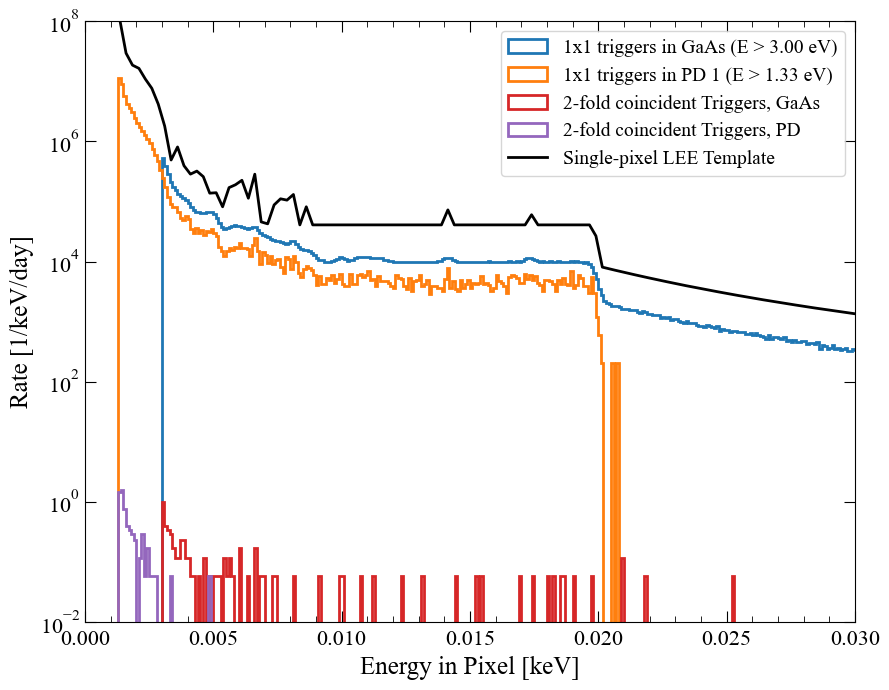

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
keV_bins = np.arange(0, 50, 0.1) * 1e-3 

E_th_PD = 1.33 - 0 * PD_energy_resolution
E_th_GaAs = 3.0

####################
# 1-fold coincidence
####################

single_pixel = E0_full > E_th_GaAs
duration_days = eff_exposure_GaAs_hours / 24
ax.hist(E0_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C0', lw=2,
        label=f'1x1 triggers in GaAs (E > {E_th_GaAs:.2f} eV)')
hist_E_E0_single, bin_edges = np.histogram(E0_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_GaAs = sum(hist_E_E0_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in GaAs: {duration_days:.2f} days')

single_pixel = E1_full > E_th_PD
duration_days = eff_exposure_PD1_hours / 24
ax.hist(E1_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C1', lw=2,
        label=f'1x1 triggers in PD 1 (E > {E_th_PD:.2f} eV)')
hist_E_E1_single, bin_edges = np.histogram(E1_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_PD_A = sum(hist_E_E1_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in PD 1: {duration_days:.2f} days')

####################
# 2-fold coincidence
####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (delta_delta_full < 9)
detected_overall = np.copy(detected)
duration_days = eff_exposure_per_run_PD1_hours * eff_exposure_per_run_GaAs_hours / run_length_hours / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C3', lw=2,
        label='2-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C4', lw=2,
        label='2-fold coincident Triggers, PD')

hist_E_2fold_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_2fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_2fold = sum(hist_E_2fold_GaAs * np.diff(bin_edges))

print(f'Effective 2-fold PD exposure: {duration_days:.2f} days')

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + f'LEE_2fold_PD_{E_th_PD:.2f}_GaAs_{E_th_GaAs:.1f}.txt',
           np.column_stack((E_save, hist_E_2fold_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')

# ####################
# # Wrapping up
# ####################


E_arr = np.linspace(0.1, 50, 200) * 1e-3
dRdE_arr = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_arr)
ax.plot(E_arr, dRdE_arr * 86400, color='k', label='Single-pixel LEE Template', lw=2)

ax.set_yscale('log')
ax.set_xlabel('Energy in Pixel [keV]')
ax.set_ylabel('Rate [1/keV/day]')
ax.set_ylim([1e-2, 1e8])
ax.set_xlim([0, 30e-3])

ax.legend(loc='upper right', fontsize=14)
fig.tight_layout()
fig.show()

print(f'\nRates [1/day/module]:')
print(f'2-fold in GaAs, with either PD: {R_coincident_2fold:.2e}')
print(f'Number of coincident events: {sum(detected):,}')

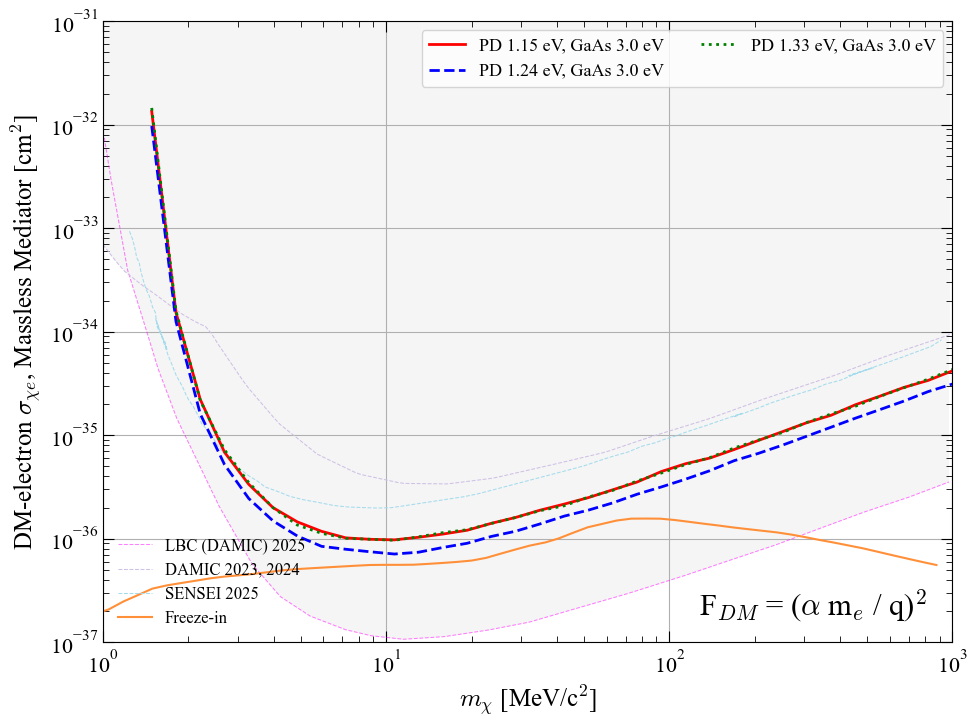

In [10]:
fig, ax, handles = load_and_plot_existing(ER_model='massless', lw=0.75, leg=True, leg_params={'loc': 'lower left', 'fontsize': 12, 'frameon': False})

handles_sens = []
handles_calculated = []

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_requirement_ER/results_massless_PD_1.15_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, 'r-', lw=2, label='PD 1.15 eV, GaAs 3.0 eV')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_requirement_ER/results_massless_PD_1.24_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, 'b--', lw=2, label='PD 1.24 eV, GaAs 3.0 eV')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_requirement_ER/results_massless_PD_1.33_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, 'g:', lw=2, label='PD 1.33 eV, GaAs 3.0 eV')
handles_calculated.append(l)

ax.text(0.97, 0.03, r'F$_{DM}$ = ($\alpha$ m$_e$ / q)$^2$', fontsize=22, transform=ax.transAxes, ha='right', va='bottom')

ax.set_xlim([1e0, 1e3])
ax.set_ylim([1e-37, 1e-31])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'DM-electron $\sigma_{\chi e}$, Massless Mediator [cm$^2$]', fontsize=18)

ax.grid('on')
leg1 = ax.legend(handles=handles_calculated, loc='upper right', fontsize=13, frameon=True, ncol=2)
ax.add_artist(leg1)
leg2 = ax.legend(handles=handles_sens, loc='lower left', fontsize=13, frameon=False)
ax.add_artist(leg2)

fig.tight_layout()
fig.show()

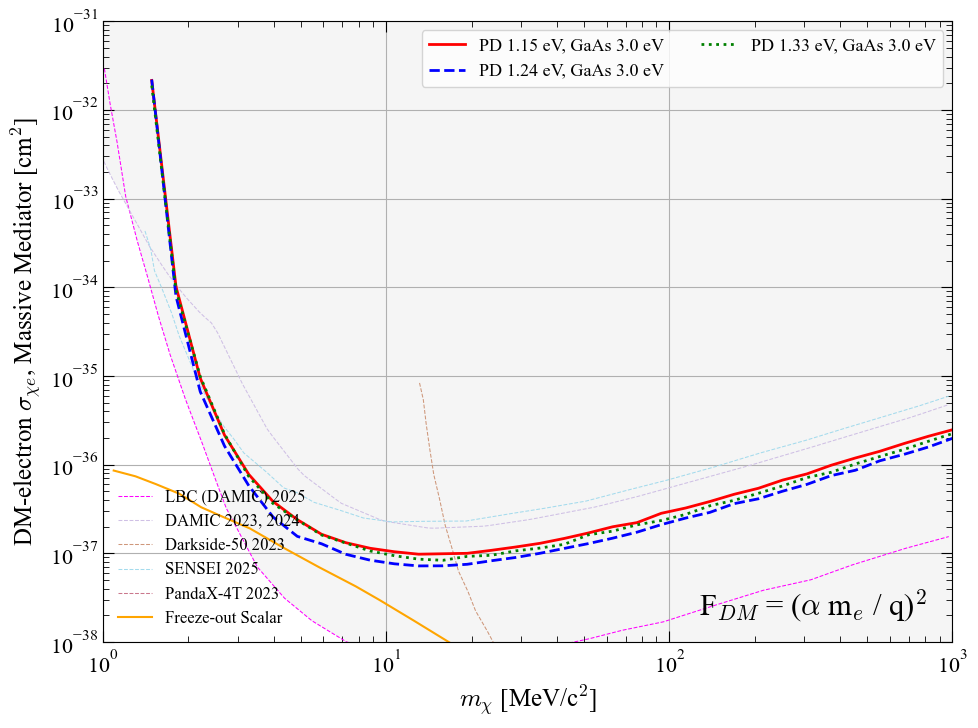

In [11]:
fig, ax, handles = load_and_plot_existing(ER_model='massive', lw=0.75, leg=True, leg_params={'loc': 'lower left', 'fontsize': 12, 'frameon': False})

handles_sens = []
handles_calculated = []

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_requirement_ER/results_massive_PD_1.15_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, 'r-', lw=2, label='PD 1.15 eV, GaAs 3.0 eV')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_requirement_ER/results_massive_PD_1.24_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, 'b--', lw=2, label='PD 1.24 eV, GaAs 3.0 eV')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_requirement_ER/results_massive_PD_1.33_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, 'g:', lw=2, label='PD 1.33 eV, GaAs 3.0 eV')
handles_calculated.append(l)

ax.text(0.97, 0.03, r'F$_{DM}$ = ($\alpha$ m$_e$ / q)$^2$', fontsize=22, transform=ax.transAxes, ha='right', va='bottom')

ax.set_xlim([1e0, 1e3])
ax.set_ylim([1e-38, 1e-31])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'DM-electron $\sigma_{\chi e}$, Massive Mediator [cm$^2$]', fontsize=18)

ax.grid('on')
leg1 = ax.legend(handles=handles_calculated, loc='upper right', fontsize=13, frameon=True, ncol=2)
ax.add_artist(leg1)
leg2 = ax.legend(handles=handles_sens, loc='lower left', fontsize=13, frameon=False)
ax.add_artist(leg2)

fig.tight_layout()
fig.show()

# ER Requirement (Worse Resolution)

In [12]:
### Load template
template = detprocess.Template(verbose=True)
template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')

# Load shared 2x1 template to get the energy scale right, but we only use the left channel template shape and PSD
channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight'

templates_td, t_sec_template, metadata = template.get_template(channel, return_metadata=True, tag='shared')
templates_td = np.reshape(templates_td[0,0], (1,1,templates_td.shape[-1]))
_, _, f_frequencies = templates_td.shape
fs = metadata['sample_rate']
pretrig = metadata['nb_pretrigger_samples']

csd, freqs_csd, _ = template.get_csd(channel, fold=False, return_metadata=True, tag='default')
csd = np.reshape(csd[0,0], (1,1,csd.shape[-1]))


### Convert to multichannel format

# Rescale template so that the energy resolution per channel is some assumed value
base_energy_resolution = 0.3977  # eV; this is the resolution of the 1x1 shared template from Run 57
GaAs_energy_resolution = 0.156
PD_energy_resolution = 0.231

E_th_PD = 1.
E_th_GaAs = 5.

E_exposure_GaAs = E_th_GaAs # The energy cutoff to calculate effective exposure. Can be the threshold or some other value.
E_exposure_PD = E_th_PD

template_OF = np.zeros((3, 3, f_frequencies))
template_OF[0, 0, :] = np.copy(templates_td)
template_OF[1, 1, :] = np.copy(templates_td) 
template_OF[2, 2, :] = np.copy(templates_td)

csd_OF = np.zeros((3, 3, f_frequencies))
csd_OF[0, 0, :] = np.copy(csd) * (GaAs_energy_resolution / base_energy_resolution)**2
csd_OF[1, 1, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2
csd_OF[2, 2, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2


INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5


In [13]:
### Load the simulation parameters
run_length_hours = 3
dirname = 'GatewayReview/gaas_requirement_ER_worse_resolution/'

E_max_PD_keV = 20e-3
E_max_GaAs_keV = 100e-3

LEE_improvement_PD = 1. # Per-volume improvement factor for the PD
LEE_volume_scale_PD = 49 * 0.3 / 100 # Ratio of PD volume to Run 57 Si volume

LEE_improvement_GaAs = 1. # Per-volume improvement factor for the GaAs
LEE_volume_scale_GaAs = 49 * 0.5 / 100 # Ratio of GaAs volume to Run 57 Si volume

# We probably don't change these
sim_trace_length = 1_250_000 * 10
sim_trace_length_s = sim_trace_length / fs  # Convert to seconds
n_simulations_per_run = int(np.floor(run_length_hours * 3600 / sim_trace_length_s))
n_traces_per_sim = int(sim_trace_length / f_frequencies)

In [14]:
### Load the simulation results

E0_full = []
E1_full = []
E2_full = []
sim_number_full = []
trigger_time_full = []
delta_delta_full = []
detected_full = []

n_runs = 0
for run_id in range(50):
    fns = glob.glob(dirname + f'my_simulation_2fold_{run_id:02d}*.pkl')
    if len(fns) == 0:
        continue
    with open(fns[0], 'rb') as f:
        results = pickle.load(f)
        
        E0_full += [e for result in results for e in result[0]]
        E1_full += [e for result in results for e in result[1]]
        E2_full += [e for result in results for e in result[2]]
        sim_number_full += [e for result in results for e in result[3]]
        trigger_time_full += [e for result in results for e in result[4]]
        delta_delta_full += [e for result in results for e in result[5]]
        detected_full += [e for result in results for e in result[6]]
        
        n_runs += 1
        del results
    print(run_id)

print(f'Loaded {n_runs} runs of simulation results.')

E0_full = np.array(E0_full)
E1_full = np.array(E1_full)
E2_full = np.array(E2_full)
sim_number_full = np.array(sim_number_full)
trigger_time_full = np.array(trigger_time_full)
delta_delta_full = np.array(delta_delta_full)
detected_full = np.array(detected_full)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
Loaded 27 runs of simulation results.


KeyboardInterrupt: 

In [ ]:
### Calculate the effective exposure in the GaAs and PD detectors, based on the observed triggers

# Exposure in a single PD detector
n_triggers_obs_PD1 = sum(E1_full > E_exposure_PD)
print(f'\nNumber of triggers observed in PD 1: {n_triggers_obs_PD1}')

E_above_th_PD1 = np.geomspace(E_exposure_PD * 1e-3, E_max_PD_keV, 250)
dRdE_above_th_PD1 = run57_lee_bkgd(scale_by=1/LEE_improvement_PD)(E_above_th_PD1)
R_above_th_PD1 = np.trapz(dRdE_above_th_PD1, E_above_th_PD1)
print(f'Expected rate of triggers in PD 1 above threshold: {R_above_th_PD1:.2e} Hz')

eff_exposure_PD1_hours = n_triggers_obs_PD1 / R_above_th_PD1 / 3600
print(f'Effective exposure in PD: {eff_exposure_PD1_hours:.2f} hours (no volume scaling or LEE improvement)')

# Exposure in the GaAs detector
n_triggers_obs_GaAs = sum(E0_full > E_exposure_GaAs)
print(f'\nNumber of triggers observed in GaAs: {n_triggers_obs_GaAs}')

E_above_th_GaAs = np.geomspace(E_exposure_GaAs * 1e-3, E_max_GaAs_keV, 250)
dRdE_above_th_GaAs = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_above_th_GaAs)
R_above_th_GaAs = np.trapz(dRdE_above_th_GaAs, E_above_th_GaAs)
print(f'Expected rate of triggers in GaAs above threshold: {R_above_th_GaAs:.2e} Hz')

eff_exposure_GaAs_hours = n_triggers_obs_GaAs / R_above_th_GaAs / 3600
print(f'Effective exposure in GaAs: {eff_exposure_GaAs_hours / 24:.2f} days (no volume scaling or LEE improvement)')

# Apply the LEE and volume scaling
print('\n##########################\n')
eff_exposure_PD1_hours /= LEE_volume_scale_PD
eff_exposure_per_run_PD1_hours = eff_exposure_PD1_hours / n_runs
eff_exposure_GaAs_hours /= LEE_volume_scale_GaAs
eff_exposure_per_run_GaAs_hours = eff_exposure_GaAs_hours / n_runs
print(f'Effective exposure in PD after LEE and volume scaling: {eff_exposure_PD1_hours:.2f} hours ({eff_exposure_per_run_PD1_hours:.2f} hours per run)')
print(f'Effective exposure in GaAs after LEE and volume scaling: {eff_exposure_GaAs_hours:.2f} hours ({eff_exposure_per_run_GaAs_hours:.2f} hours per run)')


Number of triggers observed in PD 1: 3263945
Expected rate of triggers in PD 1 above threshold: 4.41e+00 Hz
Effective exposure in PD: 205.75 hours (no volume scaling or LEE improvement)

Number of triggers observed in GaAs: 1726529
Expected rate of triggers in GaAs above threshold: 1.15e-02 Hz
Effective exposure in GaAs: 1743.22 days (no volume scaling or LEE improvement)

##########################

Effective exposure in PD after LEE and volume scaling: 1399.64 hours (51.84 hours per run)
Effective exposure in GaAs after LEE and volume scaling: 170764.53 hours (6324.61 hours per run)


Effective 1-fold exposure in GaAs: 7115.19 days
Effective 1-fold exposure in PD 1: 58.32 days
Effective 2-fold PD exposure: 122947.23 days

Rates [1/day/module]:
2-fold in GaAs, with either PD: 2.24e-02
Number of coincident events: 2,760


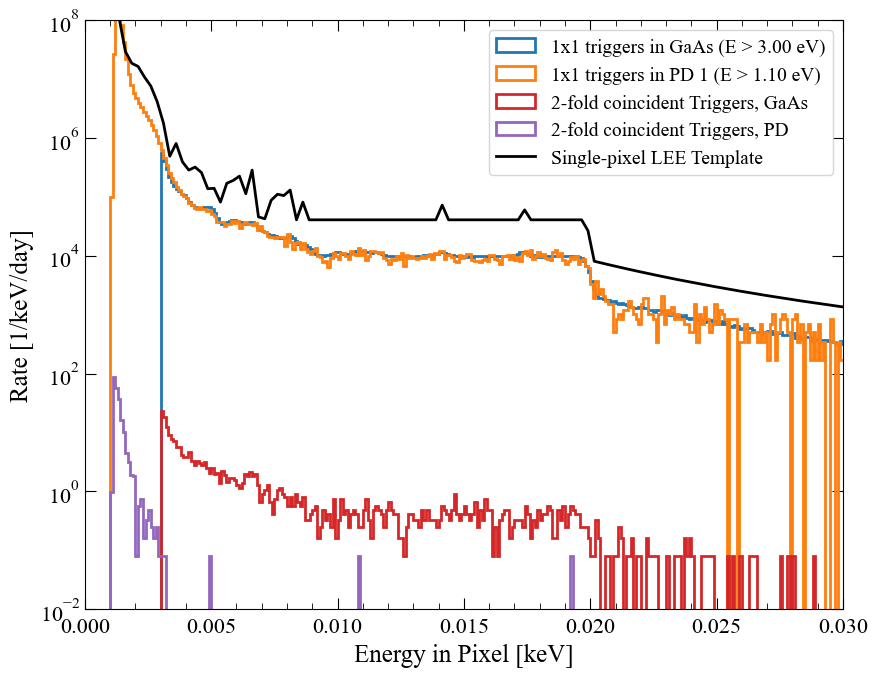

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
keV_bins = np.arange(0, 50, 0.1) * 1e-3 

E_th_PD = 1.33 - 1 * PD_energy_resolution
E_th_GaAs = 3.0

####################
# 1-fold coincidence
####################

single_pixel = E0_full > E_th_GaAs
duration_days = eff_exposure_GaAs_hours / 24
ax.hist(E0_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C0', lw=2,
        label=f'1x1 triggers in GaAs (E > {E_th_GaAs:.2f} eV)')
hist_E_E0_single, bin_edges = np.histogram(E0_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_GaAs = sum(hist_E_E0_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in GaAs: {duration_days:.2f} days')

single_pixel = E1_full > E_th_PD
duration_days = eff_exposure_PD1_hours / 24
ax.hist(E1_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C1', lw=2,
        label=f'1x1 triggers in PD 1 (E > {E_th_PD:.2f} eV)')
hist_E_E1_single, bin_edges = np.histogram(E1_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_PD_A = sum(hist_E_E1_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in PD 1: {duration_days:.2f} days')

####################
# 2-fold coincidence
####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (delta_delta_full < 9)
detected_overall = np.copy(detected)
duration_days = eff_exposure_per_run_PD1_hours * eff_exposure_per_run_GaAs_hours / run_length_hours / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C3', lw=2,
        label='2-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C4', lw=2,
        label='2-fold coincident Triggers, PD')

hist_E_2fold_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_2fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_2fold = sum(hist_E_2fold_GaAs * np.diff(bin_edges))

print(f'Effective 2-fold PD exposure: {duration_days:.2f} days')

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + f'LEE_2fold_PD_{E_th_PD:.2f}_GaAs_{E_th_GaAs:.1f}.txt',
           np.column_stack((E_save, hist_E_2fold_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')

# ####################
# # Wrapping up
# ####################


E_arr = np.linspace(0.1, 50, 200) * 1e-3
dRdE_arr = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_arr)
ax.plot(E_arr, dRdE_arr * 86400, color='k', label='Single-pixel LEE Template', lw=2)

ax.set_yscale('log')
ax.set_xlabel('Energy in Pixel [keV]')
ax.set_ylabel('Rate [1/keV/day]')
ax.set_ylim([1e-2, 1e8])
ax.set_xlim([0, 30e-3])

ax.legend(loc='upper right', fontsize=14)
fig.tight_layout()
fig.show()

print(f'\nRates [1/day/module]:')
print(f'2-fold in GaAs, with either PD: {R_coincident_2fold:.2e}')
print(f'Number of coincident events: {sum(detected):,}')

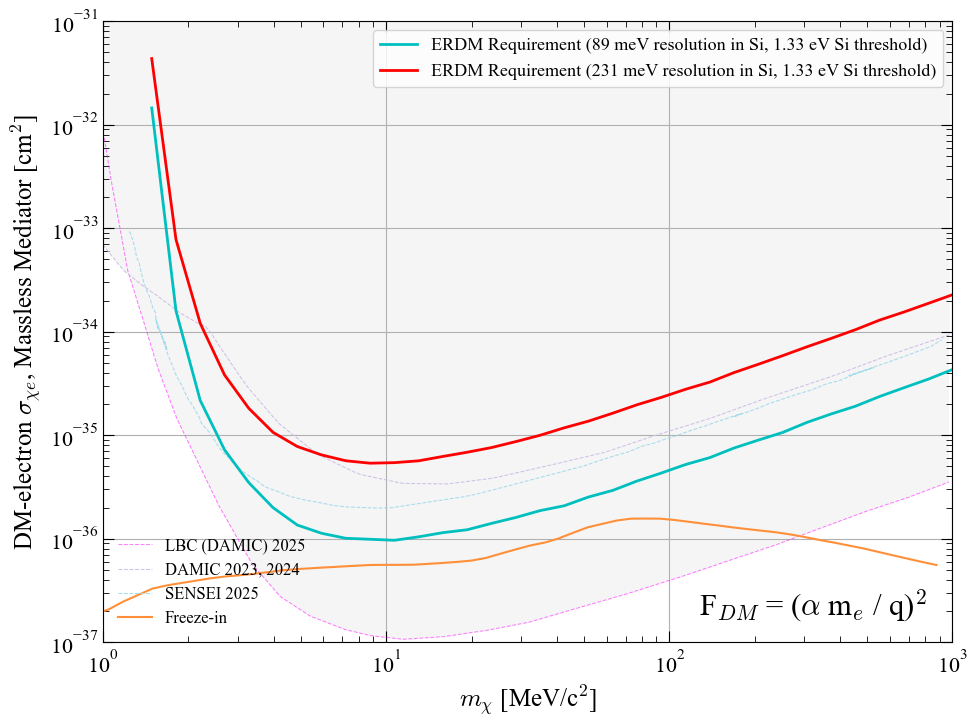

In [6]:
fig, ax, handles = load_and_plot_existing(ER_model='massless', lw=0.75, leg=True, leg_params={'loc': 'lower left', 'fontsize': 12, 'frameon': False})

handles_sens = []
handles_calculated = []

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_requirement_ER/results_massless_PD_1.33_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, 'c-', lw=2, label='ERDM Requirement (89 meV resolution in Si, 1.33 eV Si threshold)')
handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('GatewayReview/gaas_requirement_ER/results_massless_PD_1.24_GaAs_3.0/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, 'b--', lw=2, label='ERDM Requirement (89 meV resolution in Si, -1 sigma)')
# handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_requirement_ER_worse_resolution/results_massless_PD_1.33_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, 'r-', lw=2, label='ERDM Requirement (231 meV resolution in Si, 1.33 eV Si threshold)')
handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('GatewayReview/gaas_requirement_ER_worse_resolution/results_massless_PD_1.10_GaAs_3.0/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, 'g-.', lw=2, label='ERDM Requirement (231 meV resolution in Si, -1 sigma)')
# handles_calculated.append(l)

ax.text(0.97, 0.03, r'F$_{DM}$ = ($\alpha$ m$_e$ / q)$^2$', fontsize=22, transform=ax.transAxes, ha='right', va='bottom')

ax.set_xlim([1e0, 1e3])
ax.set_ylim([1e-37, 1e-31])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'DM-electron $\sigma_{\chi e}$, Massless Mediator [cm$^2$]', fontsize=18)

ax.grid('on')
leg1 = ax.legend(handles=handles_calculated, loc='upper right', fontsize=13, frameon=True)
ax.add_artist(leg1)
leg2 = ax.legend(handles=handles_sens, loc='lower left', fontsize=13, frameon=False)
ax.add_artist(leg2)

fig.tight_layout()
fig.show()

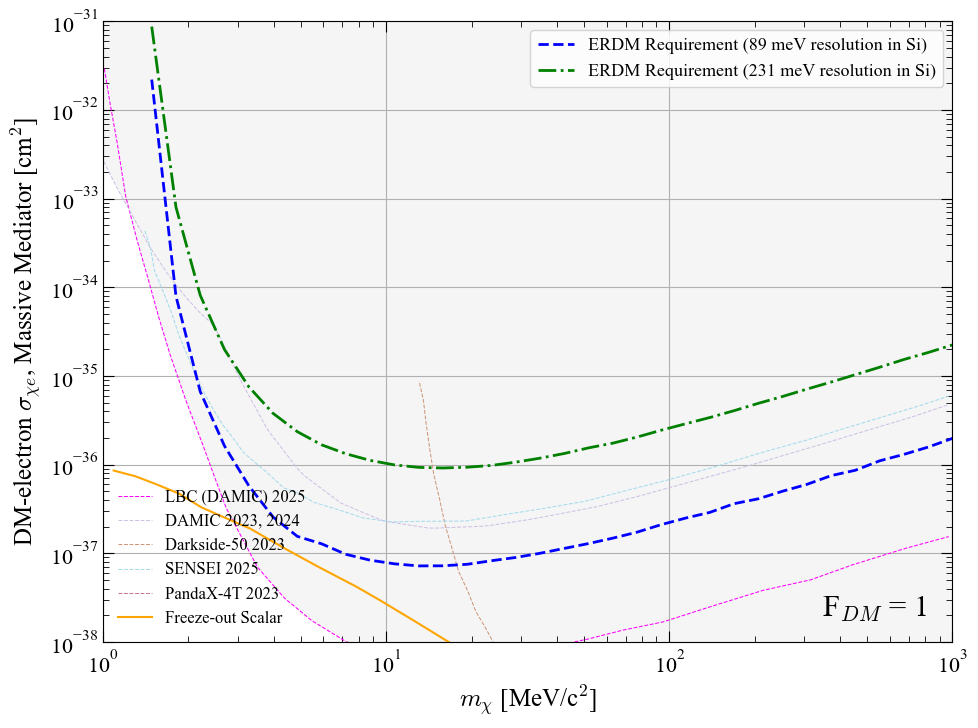

In [ ]:
fig, ax, handles = load_and_plot_existing(ER_model='massive', lw=0.75, leg=True, leg_params={'loc': 'lower left', 'fontsize': 12, 'frameon': False})

handles_sens = []
handles_calculated = []

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_requirement_ER/results_massive_PD_1.24_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, 'b--', lw=2, label='ERDM Requirement (89 meV resolution in Si)')
handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('GatewayReview/gaas_requirement_ER_worse_resolution/results_massive_PD_1.33_GaAs_3.0/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, 'r:', lw=2, label='ERDM Requirement (231 meV resolution in Si)')
# handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_requirement_ER_worse_resolution/results_massive_PD_1.10_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, 'g-.', lw=2, label='ERDM Requirement (231 meV resolution in Si)')
handles_calculated.append(l)

ax.text(0.97, 0.03, r'F$_{DM}$ = 1', fontsize=22, transform=ax.transAxes, ha='right', va='bottom')

ax.set_xlim([1e0, 1e3])
ax.set_ylim([1e-38, 1e-31])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'DM-electron $\sigma_{\chi e}$, Massive Mediator [cm$^2$]', fontsize=18)

ax.grid('on')
leg1 = ax.legend(handles=handles_calculated, loc='upper right', fontsize=13, frameon=True)
ax.add_artist(leg1)
leg2 = ax.legend(handles=handles_sens, loc='lower left', fontsize=13, frameon=False)
ax.add_artist(leg2)

fig.tight_layout()
fig.show()

# ER Goal

In [45]:
### Load template
template = detprocess.Template(verbose=True)
template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')

# Load shared 2x1 template to get the energy scale right, but we only use the left channel template shape and PSD
channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight'

templates_td, t_sec_template, metadata = template.get_template(channel, return_metadata=True, tag='shared')
templates_td = np.reshape(templates_td[0,0], (1,1,templates_td.shape[-1]))
_, _, f_frequencies = templates_td.shape
fs = metadata['sample_rate']
pretrig = metadata['nb_pretrigger_samples']

csd, freqs_csd, _ = template.get_csd(channel, fold=False, return_metadata=True, tag='default')
csd = np.reshape(csd[0,0], (1,1,csd.shape[-1]))


### Convert to multichannel format

# Rescale template so that the energy resolution per channel is some assumed value
base_energy_resolution = 0.3977  # eV; this is the resolution of the 1x1 shared template from Run 57
GaAs_energy_resolution = 0.211
PD_energy_resolution = 0.042

E_th_PD = 1.
E_th_GaAs = 5.

E_exposure_GaAs = E_th_GaAs # The energy cutoff to calculate effective exposure. Can be the threshold or some other value.
E_exposure_PD = E_th_PD

template_OF = np.zeros((3, 3, f_frequencies))
template_OF[0, 0, :] = np.copy(templates_td)
template_OF[1, 1, :] = np.copy(templates_td) 
template_OF[2, 2, :] = np.copy(templates_td)

csd_OF = np.zeros((3, 3, f_frequencies))
csd_OF[0, 0, :] = np.copy(csd) * (GaAs_energy_resolution / base_energy_resolution)**2
csd_OF[1, 1, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2
csd_OF[2, 2, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2


INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5


In [46]:
### Load the simulation parameters
run_length_hours = 3
dirname = 'GatewayReview/gaas_goal_ER/'

E_max_PD_keV = 3e-3
E_max_GaAs_keV = 100e-3

LEE_improvement_PD = 20. # Per-volume improvement factor for the PD
LEE_volume_scale_PD = 225 * 0.3 / 100 # Ratio of PD volume to Run 57 Si volume

LEE_improvement_GaAs = 20. # Per-volume improvement factor for the GaAs
LEE_volume_scale_GaAs = 225 * 4 / 100 # Ratio of GaAs volume to Run 57 Si volume

# We probably don't change these
sim_trace_length = 1_250_000 * 10
sim_trace_length_s = sim_trace_length / fs  # Convert to seconds
n_simulations_per_run = int(np.floor(run_length_hours * 3600 / sim_trace_length_s))
n_traces_per_sim = int(sim_trace_length / f_frequencies)

In [47]:
### Load the simulation results

E0_full = []
E1_full = []
E2_full = []
sim_number_full = []
trigger_time_full = []
delta_delta_full = []
detected_full = []

n_runs = 0
for run_id in range(50):
    fns = glob.glob(dirname + f'my_simulation_2fold_{run_id:02d}*.pkl')
    if len(fns) == 0:
        continue
    with open(fns[0], 'rb') as f:
        results = pickle.load(f)
        
        E0_full += [e for result in results for e in result[0]]
        E1_full += [e for result in results for e in result[1]]
        E2_full += [e for result in results for e in result[2]]
        sim_number_full += [e for result in results for e in result[3]]
        trigger_time_full += [e for result in results for e in result[4]]
        delta_delta_full += [e for result in results for e in result[5]]
        detected_full += [e for result in results for e in result[6]]
        
        n_runs += 1
        del results
    print(run_id)

print(f'Loaded {n_runs} runs of simulation results.')

E0_full = np.array(E0_full)
E1_full = np.array(E1_full)
E2_full = np.array(E2_full)
sim_number_full = np.array(sim_number_full)
trigger_time_full = np.array(trigger_time_full)
delta_delta_full = np.array(delta_delta_full)
detected_full = np.array(detected_full)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
Loaded 18 runs of simulation results.


In [48]:
### Calculate the effective exposure in the GaAs and PD detectors, based on the observed triggers

# Exposure in a single PD detector
n_triggers_obs_PD1 = sum(E1_full > E_exposure_PD)
print(f'\nNumber of triggers observed in PD 1: {n_triggers_obs_PD1}')

E_above_th_PD1 = np.geomspace(E_exposure_PD * 1e-3, E_max_PD_keV, 250)
dRdE_above_th_PD1 = run57_lee_bkgd(scale_by=1/LEE_improvement_PD)(E_above_th_PD1)
R_above_th_PD1 = np.trapz(dRdE_above_th_PD1, E_above_th_PD1)
print(f'Expected rate of triggers in PD 1 above threshold: {R_above_th_PD1:.2e} Hz')

eff_exposure_PD1_hours = n_triggers_obs_PD1 / R_above_th_PD1 / 3600
print(f'Effective exposure in PD: {eff_exposure_PD1_hours:.2f} hours (no volume scaling or LEE improvement)')

# Exposure in the GaAs detector
n_triggers_obs_GaAs = sum(E0_full > E_exposure_GaAs)
print(f'\nNumber of triggers observed in GaAs: {n_triggers_obs_GaAs}')

E_above_th_GaAs = np.geomspace(E_exposure_GaAs * 1e-3, E_max_GaAs_keV, 250)
dRdE_above_th_GaAs = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_above_th_GaAs)
R_above_th_GaAs = np.trapz(dRdE_above_th_GaAs, E_above_th_GaAs)
print(f'Expected rate of triggers in GaAs above threshold: {R_above_th_GaAs:.2e} Hz')

eff_exposure_GaAs_hours = n_triggers_obs_GaAs / R_above_th_GaAs / 3600
print(f'Effective exposure in GaAs: {eff_exposure_GaAs_hours / 24:.2f} days (no volume scaling or LEE improvement)')

# Apply the LEE and volume scaling
print('\n##########################\n')
eff_exposure_PD1_hours /= LEE_volume_scale_PD
eff_exposure_per_run_PD1_hours = eff_exposure_PD1_hours / n_runs
eff_exposure_GaAs_hours /= LEE_volume_scale_GaAs
eff_exposure_per_run_GaAs_hours = eff_exposure_GaAs_hours / n_runs
print(f'Effective exposure in PD after LEE and volume scaling: {eff_exposure_PD1_hours:.2f} hours ({eff_exposure_per_run_PD1_hours:.2f} hours per run)')
print(f'Effective exposure in GaAs after LEE and volume scaling: {eff_exposure_GaAs_hours:.2f} hours ({eff_exposure_per_run_GaAs_hours:.2f} hours per run)')


Number of triggers observed in PD 1: 7683732
Expected rate of triggers in PD 1 above threshold: 2.19e-01 Hz
Effective exposure in PD: 9749.70 hours (no volume scaling or LEE improvement)

Number of triggers observed in GaAs: 1907176
Expected rate of triggers in GaAs above threshold: 5.73e-04 Hz
Effective exposure in GaAs: 38512.29 days (no volume scaling or LEE improvement)

##########################

Effective exposure in PD after LEE and volume scaling: 14444.00 hours (802.44 hours per run)
Effective exposure in GaAs after LEE and volume scaling: 102699.45 hours (5705.53 hours per run)


Effective 1-fold exposure in GaAs: 4279.14 days
Effective 1-fold exposure in PD 1: 601.83 days
Effective 2-fold PD exposure: 1144591.37 days

Rates [1/day/module]:
2-fold in GaAs, with either PD: 3.74e-04
Number of coincident events: 428


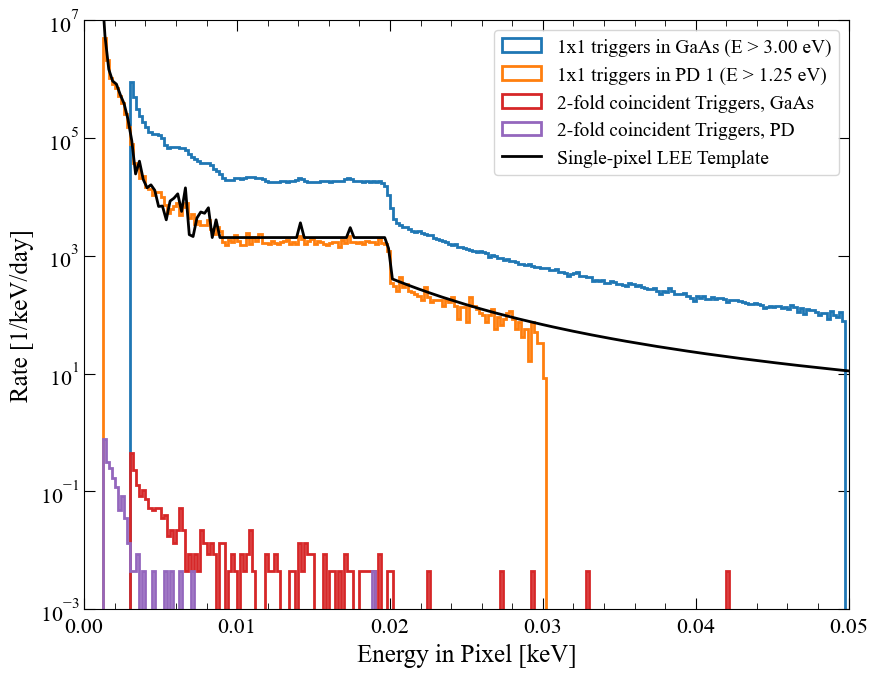

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
keV_bins = np.arange(0, 50, 0.2) * 1e-3 

E_th_PD = 1.33 - 2 * PD_energy_resolution
E_th_GaAs = 3.0

####################
# 1-fold coincidence
####################

single_pixel = E0_full > E_th_GaAs
duration_days = eff_exposure_GaAs_hours / 24
ax.hist(E0_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C0', lw=2,
        label=f'1x1 triggers in GaAs (E > {E_th_GaAs:.2f} eV)')
hist_E_E0_single, bin_edges = np.histogram(E0_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_GaAs = sum(hist_E_E0_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in GaAs: {duration_days:.2f} days')

single_pixel = E1_full > E_th_PD
duration_days = eff_exposure_PD1_hours / 24
ax.hist(E1_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C1', lw=2,
        label=f'1x1 triggers in PD 1 (E > {E_th_PD:.2f} eV)')
hist_E_E1_single, bin_edges = np.histogram(E1_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_PD_A = sum(hist_E_E1_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in PD 1: {duration_days:.2f} days')

####################
# 2-fold coincidence
####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (delta_delta_full < 9)
detected_overall = np.copy(detected)
duration_days = eff_exposure_per_run_PD1_hours * eff_exposure_per_run_GaAs_hours / run_length_hours / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C3', lw=2,
        label='2-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C4', lw=2,
        label='2-fold coincident Triggers, PD')

hist_E_2fold_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_2fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_2fold = sum(hist_E_2fold_GaAs * np.diff(bin_edges))

print(f'Effective 2-fold PD exposure: {duration_days:.2f} days')

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + f'LEE_2fold_PD_{E_th_PD:.2f}_GaAs_{E_th_GaAs:.1f}.txt',
           np.column_stack((E_save, hist_E_2fold_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')

# ####################
# # Wrapping up
# ####################


E_arr = np.linspace(0.1, 50, 200) * 1e-3
dRdE_arr = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_arr)
ax.plot(E_arr, dRdE_arr * 86400, color='k', label='Single-pixel LEE Template', lw=2)

ax.set_yscale('log')
ax.set_xlabel('Energy in Pixel [keV]')
ax.set_ylabel('Rate [1/keV/day]')
ax.set_ylim([1e-3, 1e7])
ax.set_xlim([0, 50e-3])

ax.legend(loc='upper right', fontsize=14)
fig.tight_layout()
fig.show()

print(f'\nRates [1/day/module]:')
print(f'2-fold in GaAs, with either PD: {R_coincident_2fold:.2e}')
print(f'Number of coincident events: {sum(detected):,}')

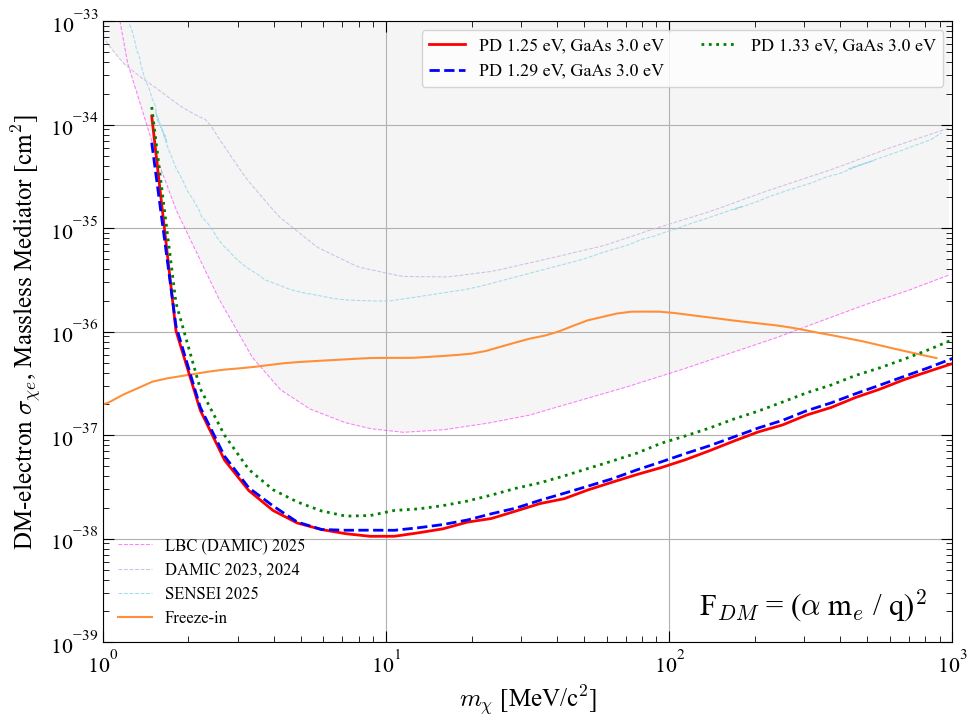

In [50]:
fig, ax, handles = load_and_plot_existing(ER_model='massless', lw=0.75, leg=True, leg_params={'loc': 'lower left', 'fontsize': 12, 'frameon': False})

handles_sens = []
handles_calculated = []

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_goal_ER/results_massless_PD_1.25_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, 'r-', lw=2, label='PD 1.25 eV, GaAs 3.0 eV')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_goal_ER/results_massless_PD_1.29_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, 'b--', lw=2, label='PD 1.29 eV, GaAs 3.0 eV')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_goal_ER/results_massless_PD_1.33_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, 'g:', lw=2, label='PD 1.33 eV, GaAs 3.0 eV')
handles_calculated.append(l)

ax.text(0.97, 0.03, r'F$_{DM}$ = ($\alpha$ m$_e$ / q)$^2$', fontsize=22, transform=ax.transAxes, ha='right', va='bottom')

ax.set_xlim([1e0, 1e3])
ax.set_ylim([1e-39, 1e-33])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'DM-electron $\sigma_{\chi e}$, Massless Mediator [cm$^2$]', fontsize=18)

ax.grid('on')
leg1 = ax.legend(handles=handles_calculated, loc='upper right', fontsize=13, frameon=True, ncol=2)
ax.add_artist(leg1)
leg2 = ax.legend(handles=handles_sens, loc='lower left', fontsize=13, frameon=False)
ax.add_artist(leg2)

fig.tight_layout()
fig.show()

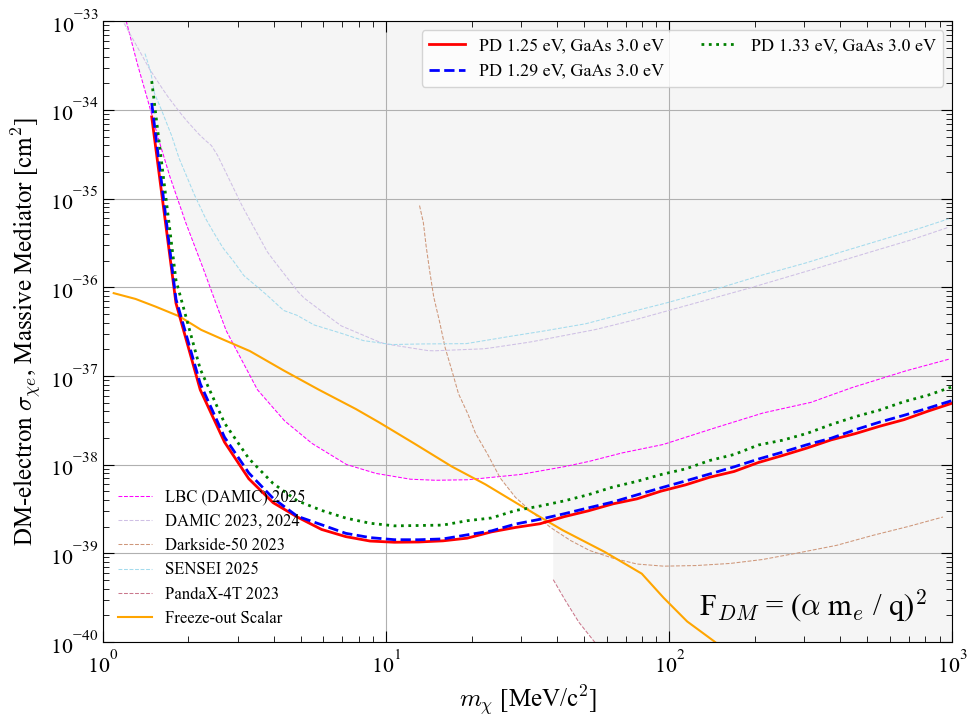

In [51]:
fig, ax, handles = load_and_plot_existing(ER_model='massive', lw=0.75, leg=True, leg_params={'loc': 'lower left', 'fontsize': 12, 'frameon': False})

handles_sens = []
handles_calculated = []

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_goal_ER/results_massive_PD_1.25_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, 'r-', lw=2, label='PD 1.25 eV, GaAs 3.0 eV')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_goal_ER/results_massive_PD_1.29_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, 'b--', lw=2, label='PD 1.29 eV, GaAs 3.0 eV')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_goal_ER/results_massive_PD_1.33_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, 'g:', lw=2, label='PD 1.33 eV, GaAs 3.0 eV')
handles_calculated.append(l)

ax.text(0.97, 0.03, r'F$_{DM}$ = ($\alpha$ m$_e$ / q)$^2$', fontsize=22, transform=ax.transAxes, ha='right', va='bottom')

ax.set_xlim([1e0, 1e3])
ax.set_ylim([1e-40, 1e-33])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'DM-electron $\sigma_{\chi e}$, Massive Mediator [cm$^2$]', fontsize=18)

ax.grid('on')
leg1 = ax.legend(handles=handles_calculated, loc='upper right', fontsize=13, frameon=True, ncol=2)
ax.add_artist(leg1)
leg2 = ax.legend(handles=handles_sens, loc='lower left', fontsize=13, frameon=False)
ax.add_artist(leg2)

fig.tight_layout()
fig.show()

# NR Requirement

## Low-Energy

In [52]:
### Load template
template = detprocess.Template(verbose=True)
template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')

# Load shared 2x1 template to get the energy scale right, but we only use the left channel template shape and PSD
channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight'

templates_td, t_sec_template, metadata = template.get_template(channel, return_metadata=True, tag='shared')
templates_td = np.reshape(templates_td[0,0], (1,1,templates_td.shape[-1]))
_, _, f_frequencies = templates_td.shape
fs = metadata['sample_rate']
pretrig = metadata['nb_pretrigger_samples']

csd, freqs_csd, _ = template.get_csd(channel, fold=False, return_metadata=True, tag='default')
csd = np.reshape(csd[0,0], (1,1,csd.shape[-1]))


### Convert to multichannel format

# Rescale template so that the energy resolution per channel is some assumed value
base_energy_resolution = 0.3977  # eV; this is the resolution of the 1x1 shared template from Run 57
GaAs_energy_resolution = 0.944
PD_energy_resolution = 0.190

E_th_PD = 1.25
E_th_GaAs = 6.

E_exposure_GaAs = E_th_GaAs # The energy cutoff to calculate effective exposure. Can be the threshold or some other value.
E_exposure_PD = E_th_PD

template_OF = np.zeros((3, 3, f_frequencies))
template_OF[0, 0, :] = np.copy(templates_td)
template_OF[1, 1, :] = np.copy(templates_td) 
template_OF[2, 2, :] = np.copy(templates_td)

csd_OF = np.zeros((3, 3, f_frequencies))
csd_OF[0, 0, :] = np.copy(csd) * (GaAs_energy_resolution / base_energy_resolution)**2
csd_OF[1, 1, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2
csd_OF[2, 2, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2


INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5


In [53]:
### Load the simulation parameters
run_length_hours = 3
dirname = 'GatewayReview/gaas_requirement_NR/low_energy/'

E_max_PD_keV = 30e-3
E_max_GaAs_keV = 100e-3

LEE_improvement_PD = 1. # Per-volume improvement factor for the PD
LEE_volume_scale_PD = 225 * 0.3 / 100 # Ratio of PD volume to Run 57 Si volume

LEE_improvement_GaAs = 1. # Per-volume improvement factor for the GaAs
LEE_volume_scale_GaAs = 225 * 4 / 100 # Ratio of GaAs volume to Run 57 Si volume

# We probably don't change these
sim_trace_length = 1_250_000 * 10
sim_trace_length_s = sim_trace_length / fs  # Convert to seconds
n_simulations_per_run = int(np.floor(run_length_hours * 3600 / sim_trace_length_s))
n_traces_per_sim = int(sim_trace_length / f_frequencies)

In [54]:
### Load the simulation results

E0_full = []
E1_full = []
E2_full = []
sim_number_full = []
trigger_time_full = []
delta_delta_full = []
detected_full = []

n_runs = 0
for run_id in range(50):
    fns = glob.glob(dirname + f'my_simulation_2fold_{run_id:02d}*.pkl')
    if len(fns) == 0:
        continue
    with open(fns[0], 'rb') as f:
        results = pickle.load(f)
        
        E0_full += [e for result in results for e in result[0]]
        E1_full += [e for result in results for e in result[1]]
        E2_full += [e for result in results for e in result[2]]
        sim_number_full += [e for result in results for e in result[3]]
        trigger_time_full += [e for result in results for e in result[4]]
        delta_delta_full += [e for result in results for e in result[5]]
        detected_full += [e for result in results for e in result[6]]
        
        n_runs += 1
        del results
    print(run_id)

print(f'Loaded {n_runs} runs of simulation results.')

E0_full = np.array(E0_full)
E1_full = np.array(E1_full)
E2_full = np.array(E2_full)
sim_number_full = np.array(sim_number_full)
trigger_time_full = np.array(trigger_time_full)
delta_delta_full = np.array(delta_delta_full)
detected_full = np.array(detected_full)


Loaded 0 runs of simulation results.


In [55]:
### Calculate the effective exposure in the GaAs and PD detectors, based on the observed triggers

# Exposure in a single PD detector
n_triggers_obs_PD1 = sum(E1_full > E_exposure_PD)
print(f'\nNumber of triggers observed in PD 1: {n_triggers_obs_PD1}')

E_above_th_PD1 = np.geomspace(E_exposure_PD * 1e-3, E_max_PD_keV, 250)
dRdE_above_th_PD1 = run57_lee_bkgd(scale_by=1/LEE_improvement_PD)(E_above_th_PD1)
R_above_th_PD1 = np.trapz(dRdE_above_th_PD1, E_above_th_PD1)
print(f'Expected rate of triggers in PD 1 above threshold: {R_above_th_PD1:.2e} Hz')

eff_exposure_PD1_hours = n_triggers_obs_PD1 / R_above_th_PD1 / 3600
print(f'Effective exposure in PD: {eff_exposure_PD1_hours:.2f} hours (no volume scaling or LEE improvement)')

# Exposure in the GaAs detector
n_triggers_obs_GaAs = sum(E0_full > E_exposure_GaAs)
print(f'\nNumber of triggers observed in GaAs: {n_triggers_obs_GaAs}')

E_above_th_GaAs = np.geomspace(E_exposure_GaAs * 1e-3, E_max_GaAs_keV, 250)
dRdE_above_th_GaAs = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_above_th_GaAs)
R_above_th_GaAs = np.trapz(dRdE_above_th_GaAs, E_above_th_GaAs)
print(f'Expected rate of triggers in GaAs above threshold: {R_above_th_GaAs:.2e} Hz')

eff_exposure_GaAs_hours = n_triggers_obs_GaAs / R_above_th_GaAs / 3600
print(f'Effective exposure in GaAs: {eff_exposure_GaAs_hours / 24:.2f} days (no volume scaling or LEE improvement)')

# Apply the LEE and volume scaling
print('\n##########################\n')
eff_exposure_PD1_hours /= LEE_volume_scale_PD
eff_exposure_per_run_PD1_hours = eff_exposure_PD1_hours / n_runs
eff_exposure_GaAs_hours /= LEE_volume_scale_GaAs
eff_exposure_per_run_GaAs_hours = eff_exposure_GaAs_hours / n_runs
print(f'Effective exposure in PD after LEE and volume scaling: {eff_exposure_PD1_hours:.2f} hours ({eff_exposure_per_run_PD1_hours:.2f} hours per run)')
print(f'Effective exposure in GaAs after LEE and volume scaling: {eff_exposure_GaAs_hours:.2f} hours ({eff_exposure_per_run_GaAs_hours:.2f} hours per run)')


Number of triggers observed in PD 1: 0
Expected rate of triggers in PD 1 above threshold: 6.06e-01 Hz
Effective exposure in PD: 0.00 hours (no volume scaling or LEE improvement)

Number of triggers observed in GaAs: 0
Expected rate of triggers in GaAs above threshold: 9.71e-03 Hz
Effective exposure in GaAs: 0.00 days (no volume scaling or LEE improvement)

##########################

Effective exposure in PD after LEE and volume scaling: 0.00 hours (nan hours per run)
Effective exposure in GaAs after LEE and volume scaling: 0.00 hours (nan hours per run)


Effective 1-fold exposure in GaAs: 0.00 days
Effective 1-fold exposure in PD 1: 0.00 days
Effective 2-fold PD exposure: nan days


FileNotFoundError: [Errno 2] No such file or directory: 'GatewayReview/gaas_requirement_NR/low_energy/LEE_2fold_PD_0.95_GaAs_20.0.txt'

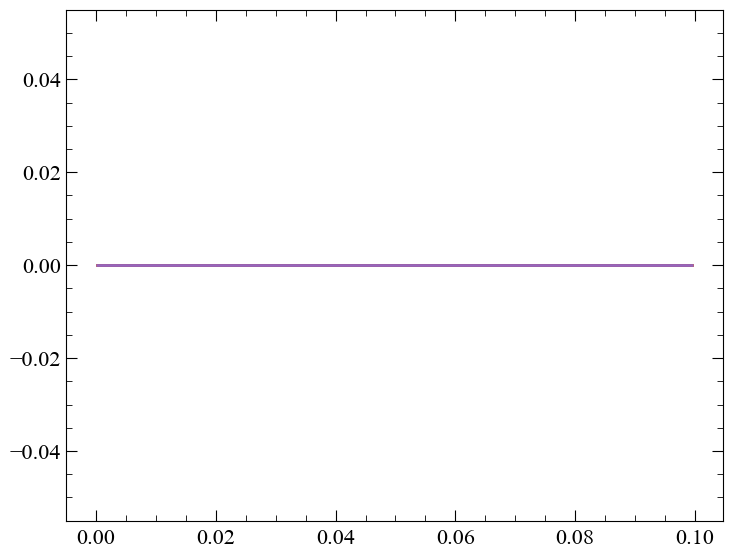

In [56]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
keV_bins = np.arange(0, 100, 0.2) * 1e-3 

E_th_PD = 1.33 - 2 * PD_energy_resolution
E_th_GaAs = 20.

####################
# 1-fold coincidence
####################

single_pixel = E0_full > E_th_GaAs
duration_days = eff_exposure_GaAs_hours / 24
ax.hist(E0_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C0', lw=2,
        label=f'1x1 triggers in GaAs (E > {E_th_GaAs:.2f} eV)')
hist_E_E0_single, bin_edges = np.histogram(E0_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_GaAs = sum(hist_E_E0_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in GaAs: {duration_days:.2f} days')

single_pixel = E1_full > E_th_PD
duration_days = eff_exposure_PD1_hours / 24
ax.hist(E1_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C1', lw=2,
        label=f'1x1 triggers in PD 1 (E > {E_th_PD:.2f} eV)')
hist_E_E1_single, bin_edges = np.histogram(E1_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_PD_A = sum(hist_E_E1_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in PD 1: {duration_days:.2f} days')

####################
# 2-fold coincidence
####################

keV_bins = np.arange(0, 100, 0.2) * 1e-3 
detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (delta_delta_full < 9)
detected_overall = np.copy(detected)
duration_days = eff_exposure_per_run_PD1_hours * eff_exposure_per_run_GaAs_hours / run_length_hours / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C3', lw=2,
        label='2-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C4', lw=2,
        label='2-fold coincident Triggers, PD')

hist_E_2fold_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_2fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_2fold = sum(hist_E_2fold_GaAs * np.diff(bin_edges))

print(f'Effective 2-fold PD exposure: {duration_days:.2f} days')

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + f'LEE_2fold_PD_{E_th_PD:.2f}_GaAs_{E_th_GaAs:.1f}.txt',
           np.column_stack((E_save, hist_E_2fold_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')

# ####################
# # Wrapping up
# ####################


E_arr = np.linspace(0.1, 100, 200) * 1e-3
dRdE_arr = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_arr)
ax.plot(E_arr, dRdE_arr * 86400, color='k', label='Single-pixel LEE Template', lw=2)

ax.set_yscale('log')
ax.set_xlabel('Energy in Pixel [keV]')
ax.set_ylabel('Rate [1/keV/day]')
ax.set_ylim([1e-2, 1e9])
ax.set_xlim([0, 100e-3])

ax.legend(loc='upper right', fontsize=14)
fig.tight_layout()
fig.show()

print(f'\nRates [1/day/module]:')
print(f'2-fold in GaAs, with either PD: {R_coincident_2fold:.2e}')
print(f'Number of coincident events: {sum(detected):,}')

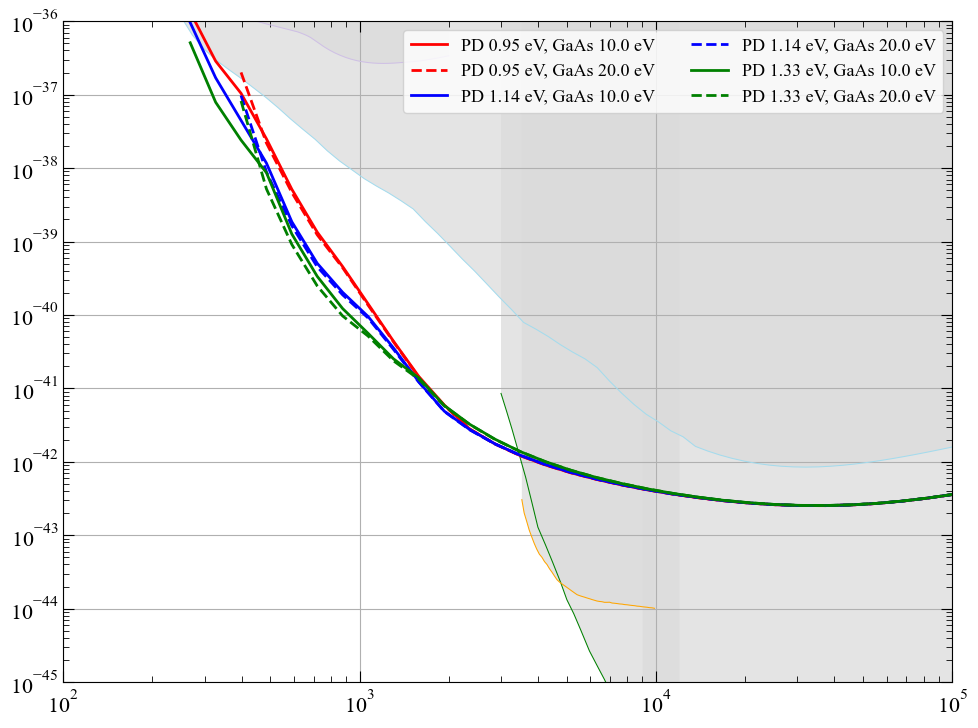

In [ ]:
fig, ax, handles_existing = load_and_plot_existing(ER_model='None', lw=0.75, leg=False, cosmic=True, migdal=False, direct=True)

handles_sens = []
handles_calculated = []

colors = ['r', 'b', 'g']
linestyles = ['-', '--']

for i, E_th_PD in enumerate([0.95, 1.14, 1.33]):
   for j, E_th_GaAs in enumerate([10.0, 20.0]):

      m_lim, x_lim = np.loadtxt(f'GatewayReview/gaas_requirement_NR/results_PD_{E_th_PD:.2f}_GaAs_{E_th_GaAs:.1f}/limit.txt', unpack=True)
      l, = ax.plot(m_lim*1e3, x_lim, color=colors[i], linestyle=linestyles[j], lw=2, label=f'PD {E_th_PD:.2f} eV, GaAs {E_th_GaAs:.1f} eV')
      handles_calculated.append(l)
      
ax.set_xlim([1e2, 1e5])
ax.set_ylim([1e-45, 1e-36])
ax.grid('on')
leg1 = ax.legend(handles=handles_calculated, loc='upper right', fontsize=13, frameon=True, ncol=2)
ax.add_artist(leg1)
leg2 = ax.legend(handles=handles_sens, loc='lower left', fontsize=13, frameon=False)
ax.add_artist(leg2)

fig.tight_layout()
fig.show()

## High-Energy

In [ ]:
### Load template
template = detprocess.Template(verbose=True)
template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')

# Load shared 2x1 template to get the energy scale right, but we only use the left channel template shape and PSD
channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight'

templates_td, t_sec_template, metadata = template.get_template(channel, return_metadata=True, tag='shared')
templates_td = np.reshape(templates_td[0,0], (1,1,templates_td.shape[-1]))
_, _, f_frequencies = templates_td.shape
fs = metadata['sample_rate']
pretrig = metadata['nb_pretrigger_samples']

csd, freqs_csd, _ = template.get_csd(channel, fold=False, return_metadata=True, tag='default')
csd = np.reshape(csd[0,0], (1,1,csd.shape[-1]))


### Convert to multichannel format

# Rescale template so that the energy resolution per channel is some assumed value
base_energy_resolution = 0.3977  # eV; this is the resolution of the 1x1 shared template from Run 57
GaAs_energy_resolution = 0.944
PD_energy_resolution = 0.190

E_th_PD = 1.25
E_th_GaAs = 20.

E_exposure_GaAs = E_th_GaAs # The energy cutoff to calculate effective exposure. Can be the threshold or some other value.
E_exposure_PD = E_th_PD

template_OF = np.zeros((3, 3, f_frequencies))
template_OF[0, 0, :] = np.copy(templates_td)
template_OF[1, 1, :] = np.copy(templates_td) 
template_OF[2, 2, :] = np.copy(templates_td)

csd_OF = np.zeros((3, 3, f_frequencies))
csd_OF[0, 0, :] = np.copy(csd) * (GaAs_energy_resolution / base_energy_resolution)**2
csd_OF[1, 1, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2
csd_OF[2, 2, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2


INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5


In [ ]:
### Load the simulation parameters
run_length_hours = 3
dirname = 'GatewayReview/gaas_requirement_NR/high_energy/'

E_max_PD_keV = 30e-3
E_max_GaAs_keV = 100e-3

LEE_improvement_PD = 1. # Per-volume improvement factor for the PD
LEE_volume_scale_PD = 225 * 0.3 / 100 # Ratio of PD volume to Run 57 Si volume

LEE_improvement_GaAs = 1. # Per-volume improvement factor for the GaAs
LEE_volume_scale_GaAs = 225 * 4 / 100 # Ratio of GaAs volume to Run 57 Si volume

# We probably don't change these
sim_trace_length = 1_250_000 * 10
sim_trace_length_s = sim_trace_length / fs  # Convert to seconds
n_simulations_per_run = int(np.floor(run_length_hours * 3600 / sim_trace_length_s))
n_traces_per_sim = int(sim_trace_length / f_frequencies)

In [ ]:
### Load the simulation results

E0_full = []
E1_full = []
E2_full = []
sim_number_full = []
trigger_time_full = []
delta_delta_full = []
detected_full = []

n_runs = 0
for run_id in range(50):
    fns = glob.glob(dirname + f'my_simulation_2fold_{run_id:02d}*.pkl')
    if len(fns) == 0:
        continue
    with open(fns[0], 'rb') as f:
        results = pickle.load(f)
        
        E0_full += [e for result in results for e in result[0]]
        E1_full += [e for result in results for e in result[1]]
        E2_full += [e for result in results for e in result[2]]
        sim_number_full += [e for result in results for e in result[3]]
        trigger_time_full += [e for result in results for e in result[4]]
        delta_delta_full += [e for result in results for e in result[5]]
        detected_full += [e for result in results for e in result[6]]
        
        n_runs += 1
        del results
    print(run_id)

print(f'Loaded {n_runs} runs of simulation results.')

E0_full = np.array(E0_full)
E1_full = np.array(E1_full)
E2_full = np.array(E2_full)
sim_number_full = np.array(sim_number_full)
trigger_time_full = np.array(trigger_time_full)
delta_delta_full = np.array(delta_delta_full)
detected_full = np.array(detected_full)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
Loaded 49 runs of simulation results.


In [ ]:
### Calculate the effective exposure in the GaAs and PD detectors, based on the observed triggers

# Exposure in a single PD detector
n_triggers_obs_PD1 = sum(E1_full > E_exposure_PD)
print(f'\nNumber of triggers observed in PD 1: {n_triggers_obs_PD1}')

E_above_th_PD1 = np.geomspace(E_exposure_PD * 1e-3, E_max_PD_keV, 250)
dRdE_above_th_PD1 = run57_lee_bkgd(scale_by=1/LEE_improvement_PD)(E_above_th_PD1)
R_above_th_PD1 = np.trapz(dRdE_above_th_PD1, E_above_th_PD1)
print(f'Expected rate of triggers in PD 1 above threshold: {R_above_th_PD1:.2e} Hz')

eff_exposure_PD1_hours = n_triggers_obs_PD1 / R_above_th_PD1 / 3600
print(f'Effective exposure in PD: {eff_exposure_PD1_hours:.2f} hours (no volume scaling or LEE improvement)')

# Exposure in the GaAs detector
n_triggers_obs_GaAs = sum(E0_full > E_exposure_GaAs)
print(f'\nNumber of triggers observed in GaAs: {n_triggers_obs_GaAs}')

E_above_th_GaAs = np.geomspace(E_exposure_GaAs * 1e-3, E_max_GaAs_keV, 250)
dRdE_above_th_GaAs = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_above_th_GaAs)
R_above_th_GaAs = np.trapz(dRdE_above_th_GaAs, E_above_th_GaAs)
print(f'Expected rate of triggers in GaAs above threshold: {R_above_th_GaAs:.2e} Hz')

eff_exposure_GaAs_hours = n_triggers_obs_GaAs / R_above_th_GaAs / 3600
print(f'Effective exposure in GaAs: {eff_exposure_GaAs_hours / 24:.2f} days (no volume scaling or LEE improvement)')

# Apply the LEE and volume scaling
print('\n##########################\n')
eff_exposure_PD1_hours /= LEE_volume_scale_PD
eff_exposure_per_run_PD1_hours = eff_exposure_PD1_hours / n_runs
eff_exposure_GaAs_hours /= LEE_volume_scale_GaAs
eff_exposure_per_run_GaAs_hours = eff_exposure_GaAs_hours / n_runs
print(f'Effective exposure in PD after LEE and volume scaling: {eff_exposure_PD1_hours:.2f} hours ({eff_exposure_per_run_PD1_hours:.2f} hours per run)')
print(f'Effective exposure in GaAs after LEE and volume scaling: {eff_exposure_GaAs_hours:.2f} hours ({eff_exposure_per_run_GaAs_hours:.2f} hours per run)')


Number of triggers observed in PD 1: 210667
Expected rate of triggers in PD 1 above threshold: 6.06e-01 Hz
Effective exposure in PD: 96.50 hours (no volume scaling or LEE improvement)

Number of triggers observed in GaAs: 5482834
Expected rate of triggers in GaAs above threshold: 5.90e-04 Hz
Effective exposure in GaAs: 107616.62 days (no volume scaling or LEE improvement)

##########################

Effective exposure in PD after LEE and volume scaling: 142.96 hours (2.92 hours per run)
Effective exposure in GaAs after LEE and volume scaling: 286977.66 hours (5856.69 hours per run)


Effective 1-fold exposure in GaAs: 11957.40 days
Effective 1-fold exposure in PD 1: 5.96 days
Effective 2-fold PD exposure: 11628.60 days

Rates [1/day/module]:
2-fold in GaAs, with either PD: 2.63e-02
Number of coincident events: 313


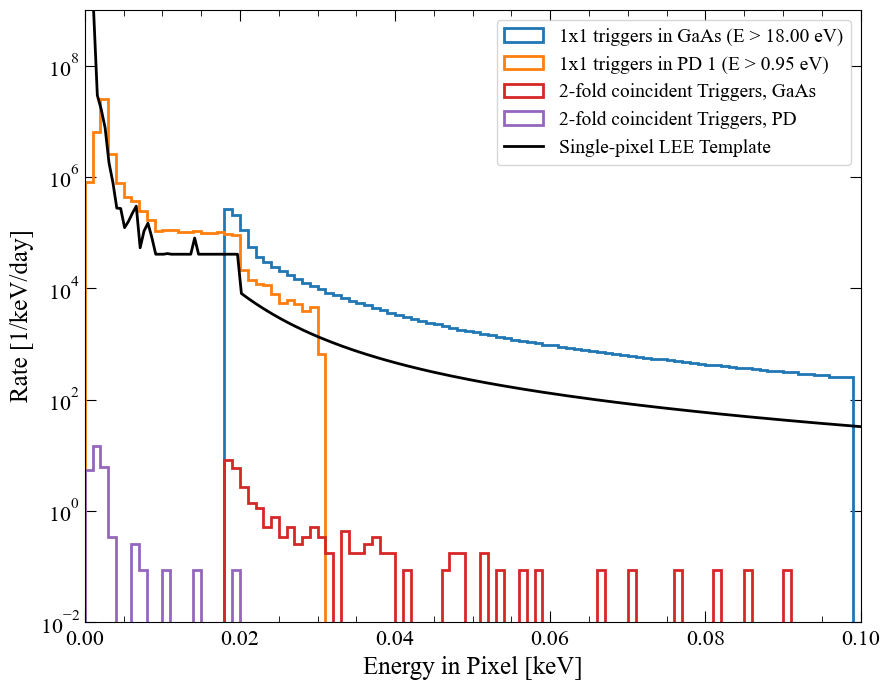

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
keV_bins = np.arange(0, 100, 1) * 1e-3 

E_th_PD = 1.33 - 2 * PD_energy_resolution
E_th_GaAs = 18.

####################
# 1-fold coincidence
####################

single_pixel = E0_full > E_th_GaAs
duration_days = eff_exposure_GaAs_hours / 24
ax.hist(E0_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C0', lw=2,
        label=f'1x1 triggers in GaAs (E > {E_th_GaAs:.2f} eV)')
hist_E_E0_single, bin_edges = np.histogram(E0_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_GaAs = sum(hist_E_E0_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in GaAs: {duration_days:.2f} days')

single_pixel = E1_full > E_th_PD
duration_days = eff_exposure_PD1_hours / 24
ax.hist(E1_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C1', lw=2,
        label=f'1x1 triggers in PD 1 (E > {E_th_PD:.2f} eV)')
hist_E_E1_single, bin_edges = np.histogram(E1_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_PD_A = sum(hist_E_E1_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in PD 1: {duration_days:.2f} days')

####################
# 2-fold coincidence
####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (delta_delta_full < 9)
detected_overall = np.copy(detected)
duration_days = eff_exposure_per_run_PD1_hours * eff_exposure_per_run_GaAs_hours / run_length_hours / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C3', lw=2,
        label='2-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C4', lw=2,
        label='2-fold coincident Triggers, PD')

hist_E_2fold_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_2fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_2fold = sum(hist_E_2fold_GaAs * np.diff(bin_edges))

print(f'Effective 2-fold PD exposure: {duration_days:.2f} days')

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + f'LEE_2fold_PD_{E_th_PD:.2f}_GaAs_{E_th_GaAs:.1f}.txt',
           np.column_stack((E_save, hist_E_2fold_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')

# ####################
# # Wrapping up
# ####################


E_arr = np.linspace(0.1, 100, 200) * 1e-3
dRdE_arr = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_arr)
ax.plot(E_arr, dRdE_arr * 86400, color='k', label='Single-pixel LEE Template', lw=2)

ax.set_yscale('log')
ax.set_xlabel('Energy in Pixel [keV]')
ax.set_ylabel('Rate [1/keV/day]')
ax.set_ylim([1e-2, 1e9])
ax.set_xlim([0, 100e-3])

ax.legend(loc='upper right', fontsize=14)
fig.tight_layout()
fig.show()

print(f'\nRates [1/day/module]:')
print(f'2-fold in GaAs, with either PD: {R_coincident_2fold:.2e}')
print(f'Number of coincident events: {sum(detected):,}')

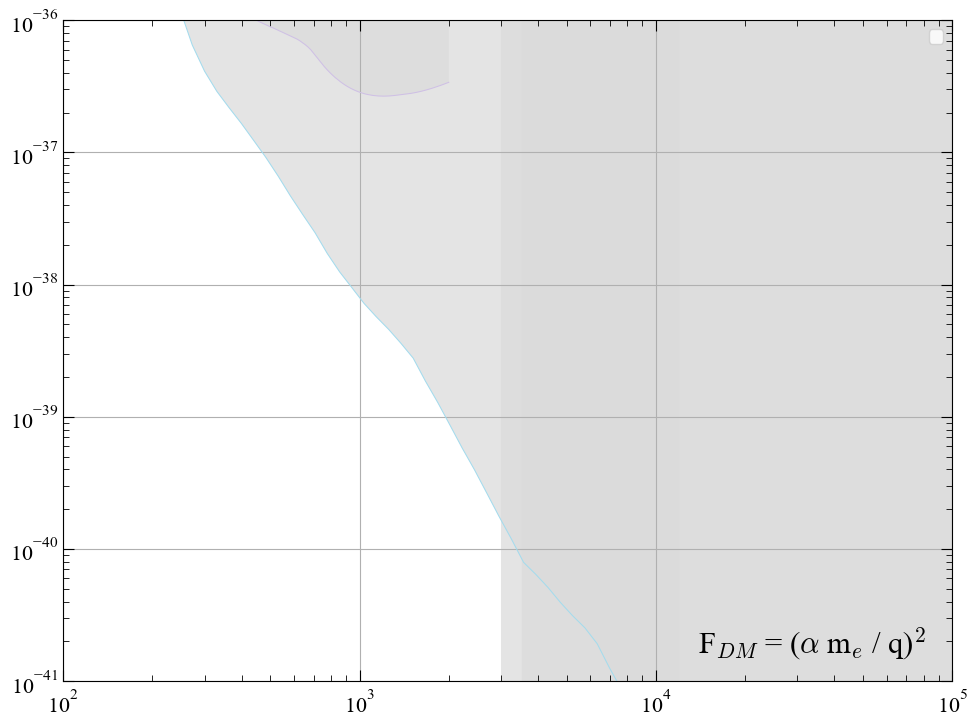

In [ ]:
fig, ax, handles_existing = load_and_plot_existing(ER_model='None', lw=0.75, leg=False, cosmic=True, migdal=False, direct=True)

handles_sens = []
handles_calculated = []


ax.text(0.97, 0.03, r'F$_{DM}$ = ($\alpha$ m$_e$ / q)$^2$', fontsize=22, transform=ax.transAxes, ha='right', va='bottom')

ax.set_xlim([1e2, 1e5])
ax.set_ylim([1e-41, 1e-36])
ax.grid('on')
leg1 = ax.legend(handles=handles_calculated, loc='upper right', fontsize=13, frameon=True, ncol=2)
ax.add_artist(leg1)
leg2 = ax.legend(handles=handles_sens, loc='lower left', fontsize=13, frameon=False)
ax.add_artist(leg2)

fig.tight_layout()
fig.show()

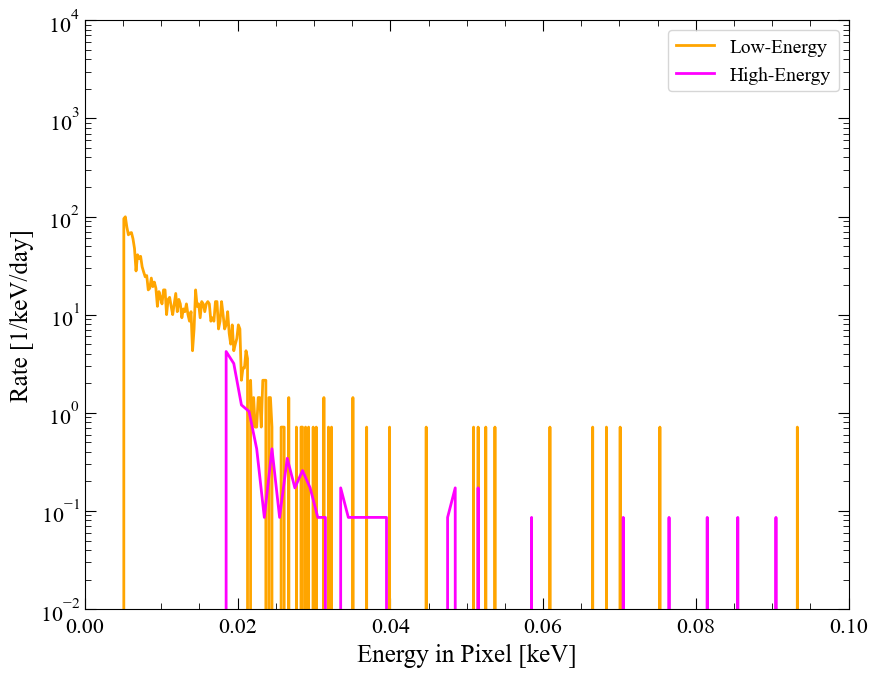

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
keV_bins = np.arange(0, 100, 1) * 1e-3 

E, dRdE = np.loadtxt('GatewayReview/gaas_requirement_NR/low_energy/LEE_2fold_PD_1.14_GaAs_5.0.txt', unpack=True)
ax.plot(E, dRdE, color='orange', lw=2, label='Low-Energy')

E, dRdE = np.loadtxt('GatewayReview/gaas_requirement_NR/high_energy/LEE_2fold_PD_1.14_GaAs_18.0.txt', unpack=True)
ax.plot(E, dRdE, color='magenta', lw=2, label='High-Energy')

ax.set_yscale('log')
ax.set_xlabel('Energy in Pixel [keV]')
ax.set_ylabel('Rate [1/keV/day]')
ax.set_ylim([1e-2, 1e4])
ax.set_xlim([0, 100e-3])

ax.legend(loc='upper right', fontsize=14)
fig.tight_layout()
fig.show()


# NR Goal

In [ ]:
### Load template
template = detprocess.Template(verbose=True)
template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')

# Load shared 2x1 template to get the energy scale right, but we only use the left channel template shape and PSD
channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight'

templates_td, t_sec_template, metadata = template.get_template(channel, return_metadata=True, tag='shared')
templates_td = np.reshape(templates_td[0,0], (1,1,templates_td.shape[-1]))
_, _, f_frequencies = templates_td.shape
fs = metadata['sample_rate']
pretrig = metadata['nb_pretrigger_samples']

csd, freqs_csd, _ = template.get_csd(channel, fold=False, return_metadata=True, tag='default')
csd = np.reshape(csd[0,0], (1,1,csd.shape[-1]))


### Convert to multichannel format

# Rescale template so that the energy resolution per channel is some assumed value
base_energy_resolution = 0.3977  # eV; this is the resolution of the 1x1 shared template from Run 57
GaAs_energy_resolution = 0.488
PD_energy_resolution = 0.0566

E_th_PD = 1.2
E_th_GaAs = 5.

E_exposure_GaAs = E_th_GaAs # The energy cutoff to calculate effective exposure. Can be the threshold or some other value.
E_exposure_PD = E_th_PD

template_OF = np.zeros((3, 3, f_frequencies))
template_OF[0, 0, :] = np.copy(templates_td)
template_OF[1, 1, :] = np.copy(templates_td) 
template_OF[2, 2, :] = np.copy(templates_td)

csd_OF = np.zeros((3, 3, f_frequencies))
csd_OF[0, 0, :] = np.copy(csd) * (GaAs_energy_resolution / base_energy_resolution)**2
csd_OF[1, 1, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2
csd_OF[2, 2, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2


INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5


In [ ]:
### Load the simulation parameters
run_length_hours = 3
dirname = 'GatewayReview/gaas_goal_NR/'

E_max_PD_keV = 50e-3
E_max_GaAs_keV = 300e-3

LEE_improvement_PD = 20. # Per-volume improvement factor for the PD
LEE_volume_scale_PD = 400 * 0.3 / 100 # Ratio of PD volume to Run 57 Si volume

LEE_improvement_GaAs = 20. # Per-volume improvement factor for the GaAs
LEE_volume_scale_GaAs = 400 * 12 / 100 # Ratio of GaAs volume to Run 57 Si volume

# We probably don't change these
sim_trace_length = 1_250_000 * 10
sim_trace_length_s = sim_trace_length / fs  # Convert to seconds
n_simulations_per_run = int(np.floor(run_length_hours * 3600 / sim_trace_length_s))
n_traces_per_sim = int(sim_trace_length / f_frequencies)

In [ ]:
### Load the simulation results

E0_full = []
E1_full = []
E2_full = []
sim_number_full = []
trigger_time_full = []
delta_delta_full = []
detected_full = []

n_runs = 0
for run_id in range(51):
    fns = glob.glob(dirname + f'my_simulation_2fold_{run_id:02d}*.pkl')
    if len(fns) == 0:
        continue
    with open(fns[0], 'rb') as f:
        results = pickle.load(f)
        
        E0_full += [e for result in results for e in result[0]]
        E1_full += [e for result in results for e in result[1]]
        E2_full += [e for result in results for e in result[2]]
        sim_number_full += [e for result in results for e in result[3]]
        trigger_time_full += [e for result in results for e in result[4]]
        delta_delta_full += [e for result in results for e in result[5]]
        detected_full += [e for result in results for e in result[6]]
        
        n_runs += 1
        del results
    print(run_id)

print(f'Loaded {n_runs} runs of simulation results.')

E0_full = np.array(E0_full)
E1_full = np.array(E1_full)
E2_full = np.array(E2_full)
sim_number_full = np.array(sim_number_full)
trigger_time_full = np.array(trigger_time_full)
delta_delta_full = np.array(delta_delta_full)
detected_full = np.array(detected_full)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
Loaded 51 runs of simulation results.


In [ ]:
### Calculate the effective exposure in the GaAs and PD detectors, based on the observed triggers

# Exposure in a single PD detector
n_triggers_obs_PD1 = sum(E1_full > E_exposure_PD)
print(f'\nNumber of triggers observed in PD 1: {n_triggers_obs_PD1}')

E_above_th_PD1 = np.geomspace(E_exposure_PD * 1e-3, E_max_PD_keV, 250)
dRdE_above_th_PD1 = run57_lee_bkgd(scale_by=1/LEE_improvement_PD)(E_above_th_PD1)
R_above_th_PD1 = np.trapz(dRdE_above_th_PD1, E_above_th_PD1)
print(f'Expected rate of triggers in PD 1 above threshold: {R_above_th_PD1:.2e} Hz')

eff_exposure_PD1_hours = n_triggers_obs_PD1 / R_above_th_PD1 / 3600
print(f'Effective exposure in PD: {eff_exposure_PD1_hours:.2f} hours (no volume scaling or LEE improvement)')

# Exposure in the GaAs detector
n_triggers_obs_GaAs = sum(E0_full > E_exposure_GaAs)
print(f'\nNumber of triggers observed in GaAs: {n_triggers_obs_GaAs}')

E_above_th_GaAs = np.geomspace(E_exposure_GaAs * 1e-3, E_max_GaAs_keV, 250)
dRdE_above_th_GaAs = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_above_th_GaAs)
R_above_th_GaAs = np.trapz(dRdE_above_th_GaAs, E_above_th_GaAs)
print(f'Expected rate of triggers in GaAs above threshold: {R_above_th_GaAs:.2e} Hz')

eff_exposure_GaAs_hours = n_triggers_obs_GaAs / R_above_th_GaAs / 3600
print(f'Effective exposure in GaAs: {eff_exposure_GaAs_hours / 24:.2f} days (no volume scaling or LEE improvement)')

# Apply the LEE and volume scaling
print('\n##########################\n')
eff_exposure_PD1_hours /= LEE_volume_scale_PD
eff_exposure_per_run_PD1_hours = eff_exposure_PD1_hours / n_runs
eff_exposure_GaAs_hours /= LEE_volume_scale_GaAs
eff_exposure_per_run_GaAs_hours = eff_exposure_GaAs_hours / n_runs
print(f'Effective exposure in PD after LEE and volume scaling: {eff_exposure_PD1_hours:.2f} hours ({eff_exposure_per_run_PD1_hours:.2f} hours per run)')
print(f'Effective exposure in GaAs after LEE and volume scaling: {eff_exposure_GaAs_hours:.2f} hours ({eff_exposure_per_run_GaAs_hours:.2f} hours per run)')


Number of triggers observed in PD 1: 5472209
Expected rate of triggers in PD 1 above threshold: 4.00e-02 Hz
Effective exposure in PD: 38037.30 hours (no volume scaling or LEE improvement)

Number of triggers observed in GaAs: 4457747
Expected rate of triggers in GaAs above threshold: 5.78e-04 Hz
Effective exposure in GaAs: 89208.55 days (no volume scaling or LEE improvement)

##########################

Effective exposure in PD after LEE and volume scaling: 31697.75 hours (621.52 hours per run)
Effective exposure in GaAs after LEE and volume scaling: 44604.27 hours (874.59 hours per run)


Effective 1-fold exposure in GaAs: 1858.51 days
Effective 1-fold exposure in PD 1: 1320.74 days
Effective 2-fold PD exposure: 385036.77 days

Rates [1/day/module]:
2-fold in GaAs, with either PD: 3.52e-03
Number of coincident events: 1,357


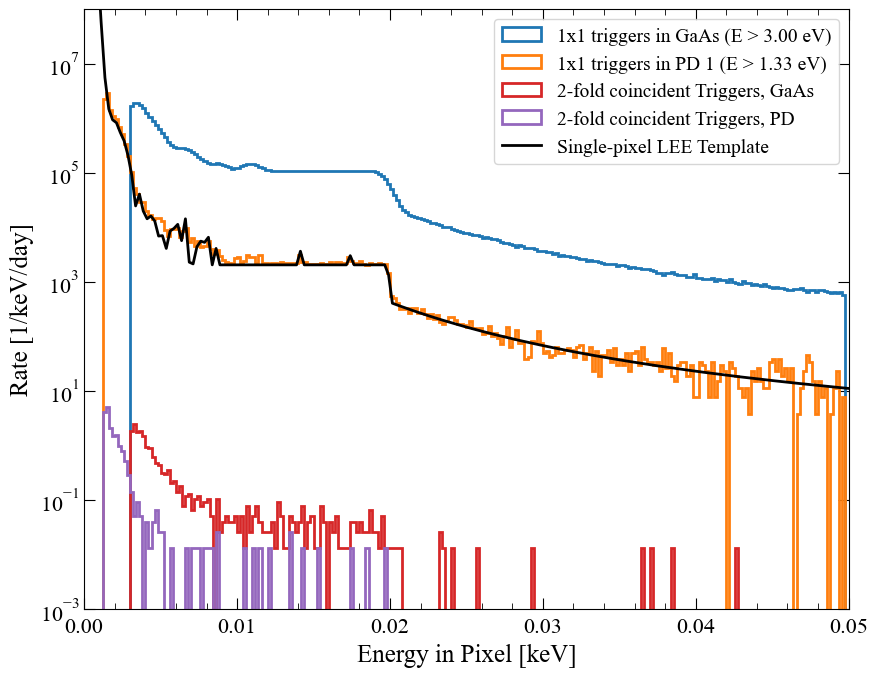

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
keV_bins = np.arange(0, 50, 0.2) * 1e-3 

E_th_PD = 1.33 - 0 * PD_energy_resolution
E_th_GaAs = 3.0

####################
# 1-fold coincidence
####################

single_pixel = E0_full > E_th_GaAs
duration_days = eff_exposure_GaAs_hours / 24
ax.hist(E0_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C0', lw=2,
        label=f'1x1 triggers in GaAs (E > {E_th_GaAs:.2f} eV)')
hist_E_E0_single, bin_edges = np.histogram(E0_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_GaAs = sum(hist_E_E0_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in GaAs: {duration_days:.2f} days')

single_pixel = E1_full > E_th_PD
duration_days = eff_exposure_PD1_hours / 24
ax.hist(E1_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C1', lw=2,
        label=f'1x1 triggers in PD 1 (E > {E_th_PD:.2f} eV)')
hist_E_E1_single, bin_edges = np.histogram(E1_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_PD_A = sum(hist_E_E1_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in PD 1: {duration_days:.2f} days')

####################
# 2-fold coincidence
####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (delta_delta_full < 9)
detected_overall = np.copy(detected)
duration_days = eff_exposure_per_run_PD1_hours * eff_exposure_per_run_GaAs_hours / run_length_hours / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C3', lw=2,
        label='2-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C4', lw=2,
        label='2-fold coincident Triggers, PD')

hist_E_2fold_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_2fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_2fold = sum(hist_E_2fold_GaAs * np.diff(bin_edges))

print(f'Effective 2-fold PD exposure: {duration_days:.2f} days')

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + f'LEE_2fold_PD_{E_th_PD:.2f}_GaAs_{E_th_GaAs:.1f}.txt',
           np.column_stack((E_save, hist_E_2fold_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')

# ####################
# # Wrapping up
# ####################


E_arr = np.linspace(0.1, 50, 200) * 1e-3
dRdE_arr = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_arr)
ax.plot(E_arr, dRdE_arr * 86400, color='k', label='Single-pixel LEE Template', lw=2)

ax.set_yscale('log')
ax.set_xlabel('Energy in Pixel [keV]')
ax.set_ylabel('Rate [1/keV/day]')
ax.set_ylim([1e-3, 1e8])
ax.set_xlim([0, 50e-3])

ax.legend(loc='upper right', fontsize=14)
fig.tight_layout()
fig.show()

print(f'\nRates [1/day/module]:')
print(f'2-fold in GaAs, with either PD: {R_coincident_2fold:.2e}')
print(f'Number of coincident events: {sum(detected):,}')

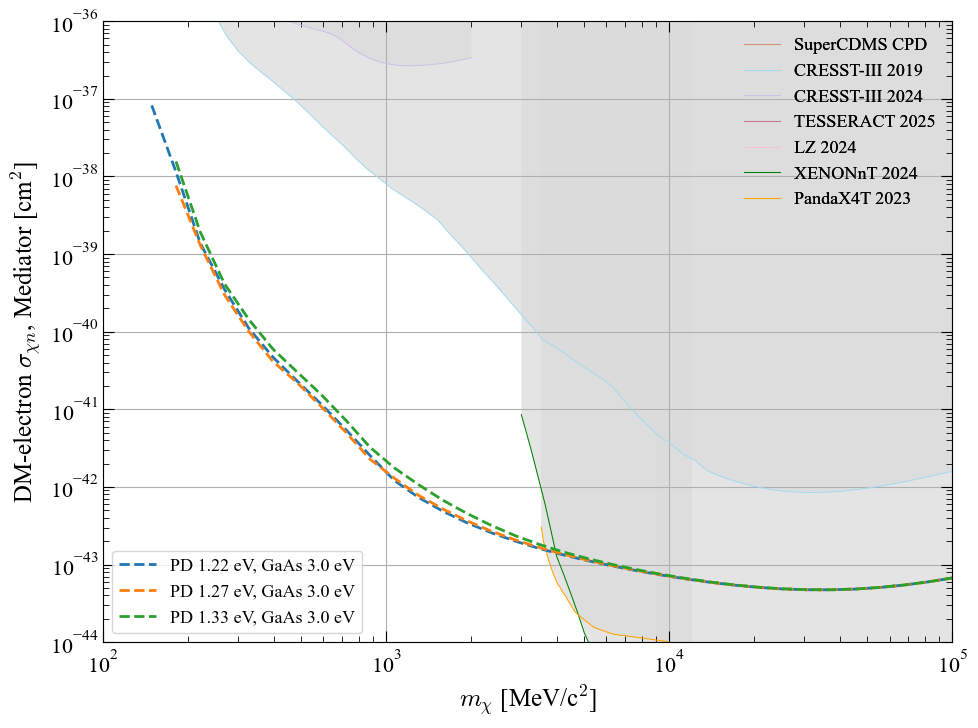

In [ ]:
fig, ax, handles_existing = load_and_plot_existing(ER_model='None', lw=0.75, leg=False, cosmic=True, migdal=False, direct=True)

handles_sens = []
handles_calculated = []

colors = ['C0', 'C1', 'C2', 'C3', 'C4']
linestyles = ['--', ':', '-.', '-']

for i, E_th_PD in enumerate([1.22, 1.27, 1.33]):
   for j, E_th_GaAs in enumerate([3.0]):

       m_lim, x_lim = np.loadtxt(f'GatewayReview/gaas_goal_NR/results_PD_{E_th_PD:.2f}_GaAs_{E_th_GaAs:.1f}/limit.txt', unpack=True)
       l, = ax.plot(m_lim*1e3, x_lim, color=colors[i], ls=linestyles[j], lw=2, label=f'PD {E_th_PD:.2f} eV, GaAs {E_th_GaAs:.1f} eV')
       handles_calculated.append(l)

ax.set_xlim([1e2, 1e5])
ax.set_ylim([1e-44, 1e-36])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'DM-electron $\sigma_{\chi n}$, Mediator [cm$^2$]', fontsize=18)

ax.grid('on')
leg1 = ax.legend(handles=handles_calculated, loc='lower left', fontsize=13, frameon=True)
ax.add_artist(leg1)
leg2 = ax.legend(handles=handles_existing, loc='upper right', fontsize=13, frameon=False)
ax.add_artist(leg2)

fig.tight_layout()
fig.show()

# NR/ER Stretch

In [ ]:
### Load template
template = detprocess.Template(verbose=True)
template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')

# Load shared 2x1 template to get the energy scale right, but we only use the left channel template shape and PSD
channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight'

templates_td, t_sec_template, metadata = template.get_template(channel, return_metadata=True, tag='shared')
templates_td = np.reshape(templates_td[0,0], (1,1,templates_td.shape[-1]))
_, _, f_frequencies = templates_td.shape
fs = metadata['sample_rate']
pretrig = metadata['nb_pretrigger_samples']

csd, freqs_csd, _ = template.get_csd(channel, fold=False, return_metadata=True, tag='default')
csd = np.reshape(csd[0,0], (1,1,csd.shape[-1]))


### Convert to multichannel format

# Rescale template so that the energy resolution per channel is some assumed value
base_energy_resolution = 0.3977  # eV; this is the resolution of the 1x1 shared template from Run 57
GaAs_energy_resolution = 0.164
PD_energy_resolution = 0.019

E_th_PD = 1.3
E_th_GaAs = 3.

E_exposure_GaAs = E_th_GaAs # The energy cutoff to calculate effective exposure. Can be the threshold or some other value.
E_exposure_PD = E_th_PD

template_OF = np.zeros((3, 3, f_frequencies))
template_OF[0, 0, :] = np.copy(templates_td)
template_OF[1, 1, :] = np.copy(templates_td) 
template_OF[2, 2, :] = np.copy(templates_td)

csd_OF = np.zeros((3, 3, f_frequencies))
csd_OF[0, 0, :] = np.copy(csd) * (GaAs_energy_resolution / base_energy_resolution)**2
csd_OF[1, 1, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2
csd_OF[2, 2, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2


INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5


In [ ]:
### Load the simulation parameters
run_length_hours = 3
dirname = 'GatewayReview/gaas_stretch/'

E_max_PD_keV = 30e-3
E_max_GaAs_keV = 100e-3

LEE_improvement_PD = 400. # Per-volume improvement factor for the PD
LEE_volume_scale_PD = 900 * 0.3 / 100 # Ratio of PD volume to Run 57 Si volume

LEE_improvement_GaAs = 400. # Per-volume improvement factor for the GaAs
LEE_volume_scale_GaAs = 900 * 12 / 100 # Ratio of GaAs volume to Run 57 Si volume

# We probably don't change these
sim_trace_length = 1_250_000 * 10
sim_trace_length_s = sim_trace_length / fs  # Convert to seconds
n_simulations_per_run = int(np.floor(run_length_hours * 3600 / sim_trace_length_s))
n_traces_per_sim = int(sim_trace_length / f_frequencies)

In [ ]:
### Load the simulation results

E0_full = []
E1_full = []
E2_full = []
sim_number_full = []
trigger_time_full = []
delta_delta_full = []
detected_full = []

n_runs = 0
for run_id in range(50):
    fns = glob.glob(dirname + f'my_simulation_2fold_{run_id:02d}*.pkl')
    if len(fns) == 0:
        continue
    with open(fns[0], 'rb') as f:
        results = pickle.load(f)
        
        E0_full += [e for result in results for e in result[0]]
        E1_full += [e for result in results for e in result[1]]
        E2_full += [e for result in results for e in result[2]]
        sim_number_full += [e for result in results for e in result[3]]
        trigger_time_full += [e for result in results for e in result[4]]
        delta_delta_full += [e for result in results for e in result[5]]
        detected_full += [e for result in results for e in result[6]]
        
        n_runs += 1
        del results
    print(run_id)

print(f'Loaded {n_runs} runs of simulation results.')

E0_full = np.array(E0_full)
E1_full = np.array(E1_full)
E2_full = np.array(E2_full)
sim_number_full = np.array(sim_number_full)
trigger_time_full = np.array(trigger_time_full)
delta_delta_full = np.array(delta_delta_full)
detected_full = np.array(detected_full)


0
1
2
3
4
9
10
11
12
13
14
15
Loaded 12 runs of simulation results.


In [ ]:
### Calculate the effective exposure in the GaAs and PD detectors, based on the observed triggers

# Exposure in a single PD detector
n_triggers_obs_PD1 = sum(E1_full > E_exposure_PD)
print(f'\nNumber of triggers observed in PD 1: {n_triggers_obs_PD1}')

E_above_th_PD1 = np.geomspace(E_exposure_PD * 1e-3, E_max_PD_keV, 250)
dRdE_above_th_PD1 = run57_lee_bkgd(scale_by=1/LEE_improvement_PD)(E_above_th_PD1)
R_above_th_PD1 = np.trapz(dRdE_above_th_PD1, E_above_th_PD1)
print(f'Expected rate of triggers in PD 1 above threshold: {R_above_th_PD1:.2e} Hz')

eff_exposure_PD1_hours = n_triggers_obs_PD1 / R_above_th_PD1 / 3600
print(f'Effective exposure in PD: {eff_exposure_PD1_hours:.2f} hours (no volume scaling or LEE improvement)')

# Exposure in the GaAs detector
n_triggers_obs_GaAs = sum(E0_full > E_exposure_GaAs)
print(f'\nNumber of triggers observed in GaAs: {n_triggers_obs_GaAs}')

E_above_th_GaAs = np.geomspace(E_exposure_GaAs * 1e-3, E_max_GaAs_keV, 250)
dRdE_above_th_GaAs = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_above_th_GaAs)
R_above_th_GaAs = np.trapz(dRdE_above_th_GaAs, E_above_th_GaAs)
print(f'Expected rate of triggers in GaAs above threshold: {R_above_th_GaAs:.2e} Hz')

eff_exposure_GaAs_hours = n_triggers_obs_GaAs / R_above_th_GaAs / 3600
print(f'Effective exposure in GaAs: {eff_exposure_GaAs_hours / 24:.2f} days (no volume scaling or LEE improvement)')

# Apply the LEE and volume scaling
print('\n##########################\n')
eff_exposure_PD1_hours /= LEE_volume_scale_PD
eff_exposure_per_run_PD1_hours = eff_exposure_PD1_hours / n_runs
eff_exposure_GaAs_hours /= LEE_volume_scale_GaAs
eff_exposure_per_run_GaAs_hours = eff_exposure_GaAs_hours / n_runs
print(f'Effective exposure in PD after LEE and volume scaling: {eff_exposure_PD1_hours:.2f} hours ({eff_exposure_per_run_PD1_hours:.2f} hours per run)')
print(f'Effective exposure in GaAs after LEE and volume scaling: {eff_exposure_GaAs_hours:.2f} hours ({eff_exposure_per_run_GaAs_hours:.2f} hours per run)')


Number of triggers observed in PD 1: 3919124
Expected rate of triggers in PD 1 above threshold: 1.21e-03 Hz
Effective exposure in PD: 899790.93 hours (no volume scaling or LEE improvement)

Number of triggers observed in GaAs: 2853777
Expected rate of triggers in GaAs above threshold: 6.29e-05 Hz
Effective exposure in GaAs: 525425.43 days (no volume scaling or LEE improvement)

##########################

Effective exposure in PD after LEE and volume scaling: 333255.90 hours (27771.33 hours per run)
Effective exposure in GaAs after LEE and volume scaling: 116761.21 hours (9730.10 hours per run)


Effective 1-fold exposure in GaAs: 4865.05 days
Effective 1-fold exposure in PD 1: 13885.66 days
Effective 2-fold PD exposure: 45036297.52 days

Rates [1/day/module]:
2-fold in GaAs, with either PD: 1.55e-05
Number of coincident events: 697


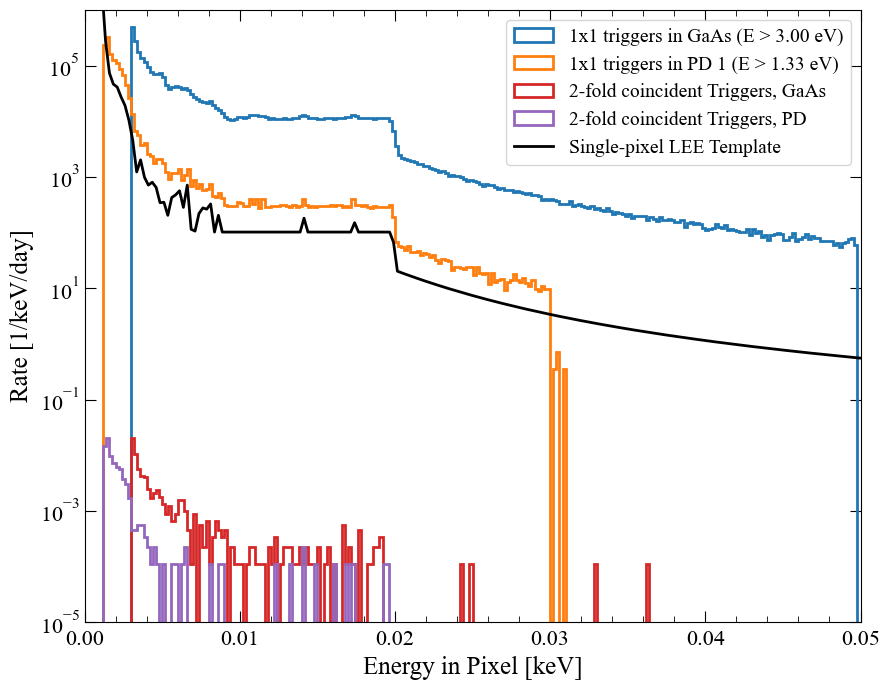

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
keV_bins = np.arange(0, 50, 0.2) * 1e-3 

E_th_PD = 1.33 - 0 * PD_energy_resolution
E_th_GaAs = 3.0

####################
# 1-fold coincidence
####################

single_pixel = E0_full > E_th_GaAs
duration_days = eff_exposure_GaAs_hours / 24
ax.hist(E0_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C0', lw=2,
        label=f'1x1 triggers in GaAs (E > {E_th_GaAs:.2f} eV)')
hist_E_E0_single, bin_edges = np.histogram(E0_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_GaAs = sum(hist_E_E0_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in GaAs: {duration_days:.2f} days')

single_pixel = E1_full > E_th_PD
duration_days = eff_exposure_PD1_hours / 24
ax.hist(E1_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C1', lw=2,
        label=f'1x1 triggers in PD 1 (E > {E_th_PD:.2f} eV)')
hist_E_E1_single, bin_edges = np.histogram(E1_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_PD_A = sum(hist_E_E1_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in PD 1: {duration_days:.2f} days')

####################
# 2-fold coincidence
####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (delta_delta_full < 9)
detected_overall = np.copy(detected)
duration_days = eff_exposure_per_run_PD1_hours * eff_exposure_per_run_GaAs_hours / run_length_hours / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C3', lw=2,
        label='2-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C4', lw=2,
        label='2-fold coincident Triggers, PD')

hist_E_2fold_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_2fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_2fold = sum(hist_E_2fold_GaAs * np.diff(bin_edges))

print(f'Effective 2-fold PD exposure: {duration_days:.2f} days')

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + f'LEE_2fold_PD_{E_th_PD:.2f}_GaAs_{E_th_GaAs:.1f}.txt',
           np.column_stack((E_save, hist_E_2fold_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')

# ####################
# # Wrapping up
# ####################


E_arr = np.linspace(0.1, 50, 200) * 1e-3
dRdE_arr = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_arr)
ax.plot(E_arr, dRdE_arr * 86400, color='k', label='Single-pixel LEE Template', lw=2)

ax.set_yscale('log')
ax.set_xlabel('Energy in Pixel [keV]')
ax.set_ylabel('Rate [1/keV/day]')
ax.set_ylim([1e-5, 1e6])
ax.set_xlim([0, 50e-3])

ax.legend(loc='upper right', fontsize=14)
fig.tight_layout()
fig.show()

print(f'\nRates [1/day/module]:')
print(f'2-fold in GaAs, with either PD: {R_coincident_2fold:.2e}')
print(f'Number of coincident events: {sum(detected):,}')

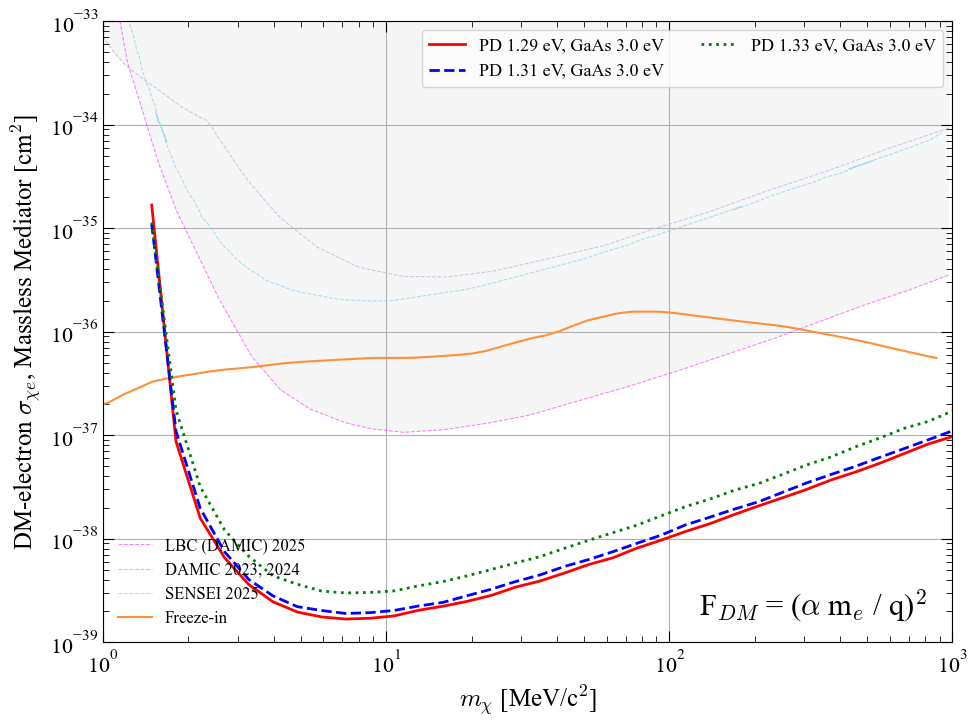

In [ ]:
fig, ax, handles = load_and_plot_existing(ER_model='massless', lw=0.75, leg=True, leg_params={'loc': 'lower left', 'fontsize': 12, 'frameon': False})

handles_sens = []
handles_calculated = []

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_stretch/results_massless_PD_1.29_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, 'r-', lw=2, label='PD 1.29 eV, GaAs 3.0 eV')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_stretch/results_massless_PD_1.31_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, 'b--', lw=2, label='PD 1.31 eV, GaAs 3.0 eV')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_stretch/results_massless_PD_1.33_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, 'g:', lw=2, label='PD 1.33 eV, GaAs 3.0 eV')
handles_calculated.append(l)

ax.text(0.97, 0.03, r'F$_{DM}$ = ($\alpha$ m$_e$ / q)$^2$', fontsize=22, transform=ax.transAxes, ha='right', va='bottom')

ax.set_xlim([1e0, 1e3])
ax.set_ylim([1e-39, 1e-33])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'DM-electron $\sigma_{\chi e}$, Massless Mediator [cm$^2$]', fontsize=18)

ax.grid('on')
leg1 = ax.legend(handles=handles_calculated, loc='upper right', fontsize=13, frameon=True, ncol=2)
ax.add_artist(leg1)
leg2 = ax.legend(handles=handles_sens, loc='lower left', fontsize=13, frameon=False)
ax.add_artist(leg2)

fig.tight_layout()
fig.show()


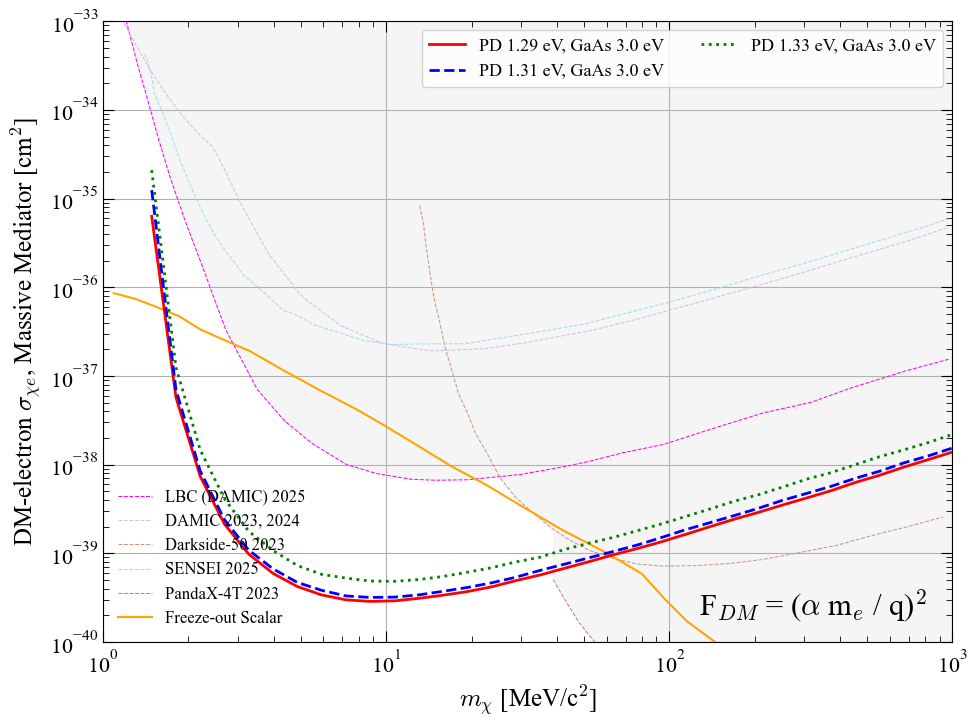

In [ ]:
fig, ax, handles = load_and_plot_existing(ER_model='massive', lw=0.75, leg=True, leg_params={'loc': 'lower left', 'fontsize': 12, 'frameon': False})

handles_sens = []
handles_calculated = []

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_stretch/results_massive_PD_1.29_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, 'r-', lw=2, label='PD 1.29 eV, GaAs 3.0 eV')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_stretch/results_massive_PD_1.31_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, 'b--', lw=2, label='PD 1.31 eV, GaAs 3.0 eV')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_stretch/results_massive_PD_1.33_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, 'g:', lw=2, label='PD 1.33 eV, GaAs 3.0 eV')
handles_calculated.append(l)

ax.text(0.97, 0.03, r'F$_{DM}$ = ($\alpha$ m$_e$ / q)$^2$', fontsize=22, transform=ax.transAxes, ha='right', va='bottom')

ax.set_xlim([1e0, 1e3])
ax.set_ylim([1e-40, 1e-33])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'DM-electron $\sigma_{\chi e}$, Massive Mediator [cm$^2$]', fontsize=18)

ax.grid('on')
leg1 = ax.legend(handles=handles_calculated, loc='upper right', fontsize=13, frameon=True, ncol=2)
ax.add_artist(leg1)
leg2 = ax.legend(handles=handles_sens, loc='lower left', fontsize=13, frameon=False)
ax.add_artist(leg2)

fig.tight_layout()
fig.show()

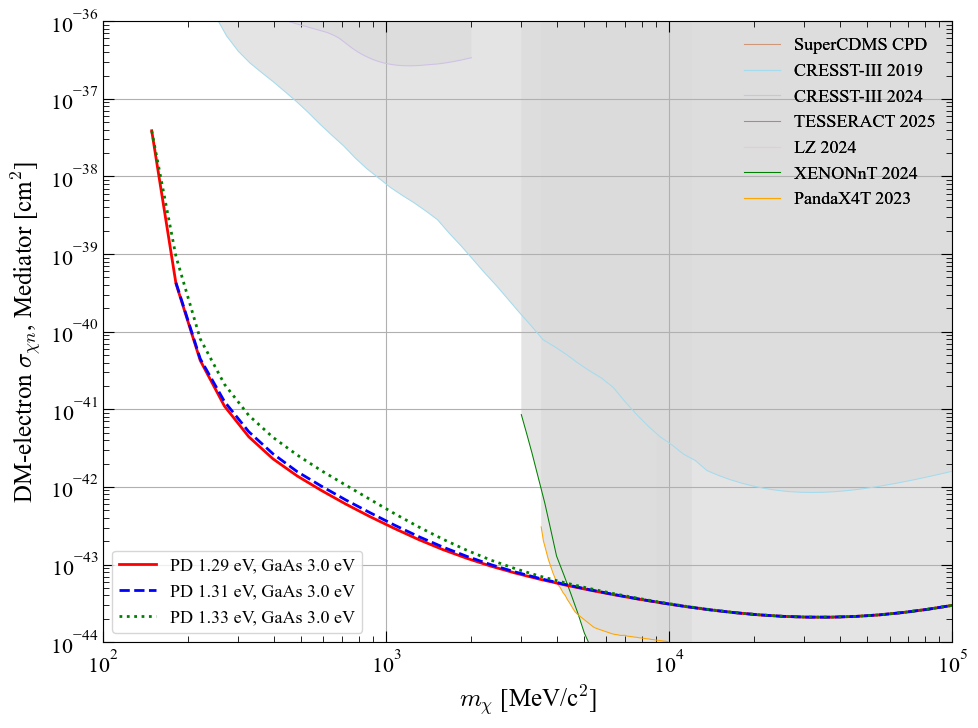

In [ ]:
fig, ax, handles_existing = load_and_plot_existing(ER_model='None', lw=0.75, leg=False, cosmic=True, migdal=False, direct=True)

handles_sens = []
handles_calculated = []

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_stretch/results_NR_PD_1.29_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, 'r-', lw=2, label='PD 1.29 eV, GaAs 3.0 eV')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_stretch/results_NR_PD_1.31_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, 'b--', lw=2, label='PD 1.31 eV, GaAs 3.0 eV')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_stretch/results_NR_PD_1.33_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, 'g:', lw=2, label='PD 1.33 eV, GaAs 3.0 eV')
handles_calculated.append(l)

ax.set_xlim([1e2, 1e5])
ax.set_ylim([1e-44, 1e-36])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'DM-electron $\sigma_{\chi n}$, Mediator [cm$^2$]', fontsize=18)

ax.grid('on')
leg1 = ax.legend(handles=handles_calculated, loc='lower left', fontsize=13, frameon=True)
ax.add_artist(leg1)
leg2 = ax.legend(handles=handles_existing, loc='upper right', fontsize=13, frameon=False)
ax.add_artist(leg2)

fig.tight_layout()
fig.show()

# Testing

In [ ]:
### Load template
template = detprocess.Template(verbose=True)
template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')

# Load shared 2x1 template to get the energy scale right, but we only use the left channel template shape and PSD
channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight'

templates_td, t_sec_template, metadata = template.get_template(channel, return_metadata=True, tag='shared')
templates_td = np.reshape(templates_td[0,0], (1,1,templates_td.shape[-1]))
_, _, f_frequencies = templates_td.shape
fs = metadata['sample_rate']
pretrig = metadata['nb_pretrigger_samples']

csd, freqs_csd, _ = template.get_csd(channel, fold=False, return_metadata=True, tag='default')
csd = np.reshape(csd[0,0], (1,1,csd.shape[-1]))


### Convert to multichannel format

# Rescale template so that the energy resolution per channel is some assumed value
base_energy_resolution = 0.3977  # eV; this is the resolution of the 1x1 shared template from Run 57
GaAs_energy_resolution = 0.944
PD_energy_resolution = 0.190

E_th_PD = 1.
E_th_GaAs = 15.

E_exposure_GaAs = E_th_GaAs # The energy cutoff to calculate effective exposure. Can be the threshold or some other value.
E_exposure_PD = E_th_PD

template_OF = np.zeros((3, 3, f_frequencies))
template_OF[0, 0, :] = np.copy(templates_td)
template_OF[1, 1, :] = np.copy(templates_td) 
template_OF[2, 2, :] = np.copy(templates_td)

csd_OF = np.zeros((3, 3, f_frequencies))
csd_OF[0, 0, :] = np.copy(csd) * (GaAs_energy_resolution / base_energy_resolution)**2
csd_OF[1, 1, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2
csd_OF[2, 2, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2


INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5


In [ ]:
### Load the simulation parameters
run_length_hours = 3
dirname = 'GatewayReview/gaas_NR_requirement/'

E_max_PD_keV = 30e-3
E_max_GaAs_keV = 300e-3

LEE_improvement_PD = 1. # Per-volume improvement factor for the PD
LEE_volume_scale_PD = 225 * 0.3 / 100 # Ratio of PD volume to Run 57 Si volume

LEE_improvement_GaAs = 1. # Per-volume improvement factor for the GaAs
LEE_volume_scale_GaAs = 225 * 4 / 100 # Ratio of GaAs volume to Run 57 Si volume

# We probably don't change these
sim_trace_length = 1_250_000 * 10
sim_trace_length_s = sim_trace_length / fs  # Convert to seconds
n_simulations_per_run = int(np.floor(run_length_hours * 3600 / sim_trace_length_s))
n_traces_per_sim = int(sim_trace_length / f_frequencies)

In [ ]:
### Load the simulation results

E0_full = []
E1_full = []
E2_full = []
sim_number_full = []
trigger_time_full = []
delta_delta_full = []
detected_full = []

n_runs = 0
for run_id in range(50):
    fns = glob.glob(dirname + f'my_simulation_2fold_{run_id:02d}*.pkl')
    if len(fns) == 0:
        continue
    with open(fns[0], 'rb') as f:
        results = pickle.load(f)
        
        E0_full += [e for result in results for e in result[0]]
        E1_full += [e for result in results for e in result[1]]
        E2_full += [e for result in results for e in result[2]]
        sim_number_full += [e for result in results for e in result[3]]
        trigger_time_full += [e for result in results for e in result[4]]
        delta_delta_full += [e for result in results for e in result[5]]
        detected_full += [e for result in results for e in result[6]]
        
        n_runs += 1
        del results
    print(run_id)

print(f'Loaded {n_runs} runs of simulation results.')

E0_full = np.array(E0_full)
E1_full = np.array(E1_full)
E2_full = np.array(E2_full)
sim_number_full = np.array(sim_number_full)
trigger_time_full = np.array(trigger_time_full)
delta_delta_full = np.array(delta_delta_full)
detected_full = np.array(detected_full)


0
1
3
4
6
7
9
10
12
13
15
16
18
19
Loaded 14 runs of simulation results.


In [ ]:
### Calculate the effective exposure in the GaAs and PD detectors, based on the observed triggers

# Exposure in a single PD detector
n_triggers_obs_PD1 = sum(E1_full > E_exposure_PD)
print(f'\nNumber of triggers observed in PD 1: {n_triggers_obs_PD1}')

E_above_th_PD1 = np.geomspace(E_exposure_PD * 1e-3, E_max_PD_keV, 250)
dRdE_above_th_PD1 = run57_lee_bkgd(scale_by=1/LEE_improvement_PD)(E_above_th_PD1)
R_above_th_PD1 = np.trapz(dRdE_above_th_PD1, E_above_th_PD1)
print(f'Expected rate of triggers in PD 1 above threshold: {R_above_th_PD1:.2e} Hz')

eff_exposure_PD1_hours = n_triggers_obs_PD1 / R_above_th_PD1 / 3600
print(f'Effective exposure in PD: {eff_exposure_PD1_hours:.2f} hours (no volume scaling or LEE improvement)')

# Exposure in the GaAs detector
n_triggers_obs_GaAs = sum(E0_full > E_exposure_GaAs)
print(f'\nNumber of triggers observed in GaAs: {n_triggers_obs_GaAs}')

E_above_th_GaAs = np.geomspace(E_exposure_GaAs * 1e-3, E_max_GaAs_keV, 250)
dRdE_above_th_GaAs = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_above_th_GaAs)
R_above_th_GaAs = np.trapz(dRdE_above_th_GaAs, E_above_th_GaAs)
print(f'Expected rate of triggers in GaAs above threshold: {R_above_th_GaAs:.2e} Hz')

eff_exposure_GaAs_hours = n_triggers_obs_GaAs / R_above_th_GaAs / 3600
print(f'Effective exposure in GaAs: {eff_exposure_GaAs_hours / 24:.2f} days (no volume scaling or LEE improvement)')

# Apply the LEE and volume scaling
print('\n##########################\n')
eff_exposure_PD1_hours /= LEE_volume_scale_PD
eff_exposure_per_run_PD1_hours = eff_exposure_PD1_hours / n_runs
eff_exposure_GaAs_hours /= LEE_volume_scale_GaAs
eff_exposure_per_run_GaAs_hours = eff_exposure_GaAs_hours / n_runs
print(f'Effective exposure in PD after LEE and volume scaling: {eff_exposure_PD1_hours:.2f} hours ({eff_exposure_per_run_PD1_hours:.2f} hours per run)')
print(f'Effective exposure in GaAs after LEE and volume scaling: {eff_exposure_GaAs_hours:.2f} hours ({eff_exposure_per_run_GaAs_hours:.2f} hours per run)')


Number of triggers observed in PD 1: 3008519
Expected rate of triggers in PD 1 above threshold: 4.40e+00 Hz
Effective exposure in PD: 189.90 hours (no volume scaling or LEE improvement)

Number of triggers observed in GaAs: 1633899
Expected rate of triggers in GaAs above threshold: 3.00e-03 Hz
Effective exposure in GaAs: 6307.88 days (no volume scaling or LEE improvement)

##########################

Effective exposure in PD after LEE and volume scaling: 281.33 hours (20.10 hours per run)
Effective exposure in GaAs after LEE and volume scaling: 16821.00 hours (1201.50 hours per run)


Effective 2-fold PD exposure: 78.52 days

Rates [1/day]:
2-fold in GaAs, with either PD: 0.00e+00


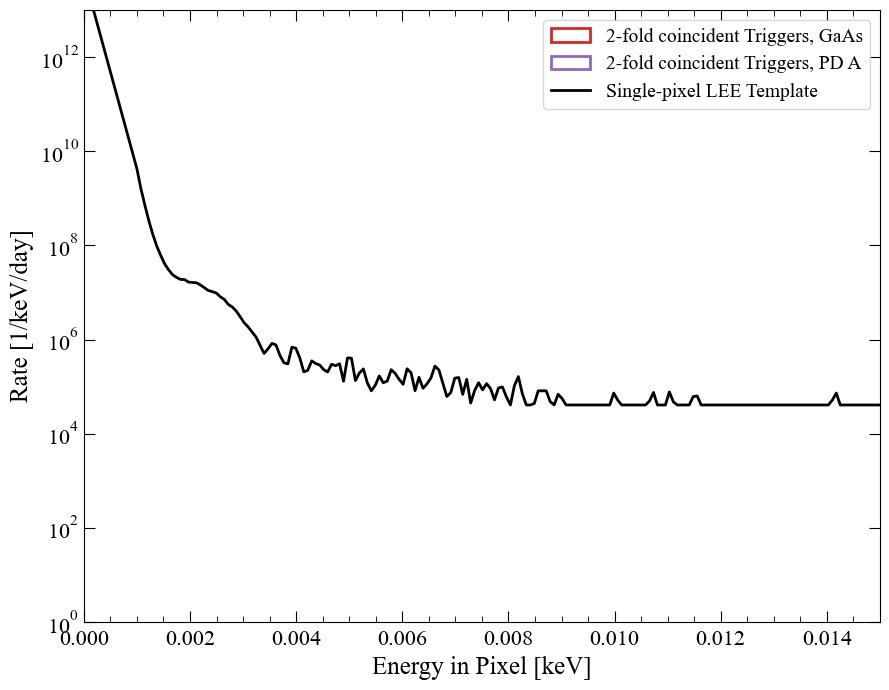

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
keV_bins = np.arange(0.1, 100, 0.02) * 1e-3


# ####################
# # 2-fold PD coincidence
# ####################

detected = (E1_full > E_th_PD) * (E2_full > E_th_PD) 

duration_days = eff_exposure_per_run_PD1_hours * eff_exposure_per_run_PD1_hours / run_length_hours / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C3', lw=2,
        label='2-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C4', lw=2,
        label='2-fold coincident Triggers, PD A')

hist_E_2fold_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_2fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_2fold = sum(hist_E_2fold_GaAs * np.diff(bin_edges))

print(f'Effective 2-fold PD exposure: {duration_days:.2f} days')

# ####################
# # Wrapping up
# ####################


E_arr = np.linspace(0.1, 15, 200) * 1e-3
dRdE_arr = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_arr)
ax.plot(E_arr, dRdE_arr * 86400, color='k', label='Single-pixel LEE Template', lw=2)

ax.set_yscale('log')
ax.set_xlabel('Energy in Pixel [keV]')
ax.set_ylabel('Rate [1/keV/day]')
ax.set_ylim([1e0, 1e13])
ax.set_xlim([0, 15e-3])

ax.legend(loc='upper right', fontsize=14)
fig.tight_layout()
fig.show()

print(f'\nRates [1/day]:')
print(f'2-fold in GaAs, with either PD: {R_coincident_2fold:.2e}')


Effective 1-fold exposure in GaAs: 700.88 days
Effective 1-fold exposure in PD 1: 11.72 days
Effective 2-fold PD exposure: 4694.74 days

Rates [1/day]:
2-fold in GaAs, with either PD: 3.56e-02
Number of coincident events: 167


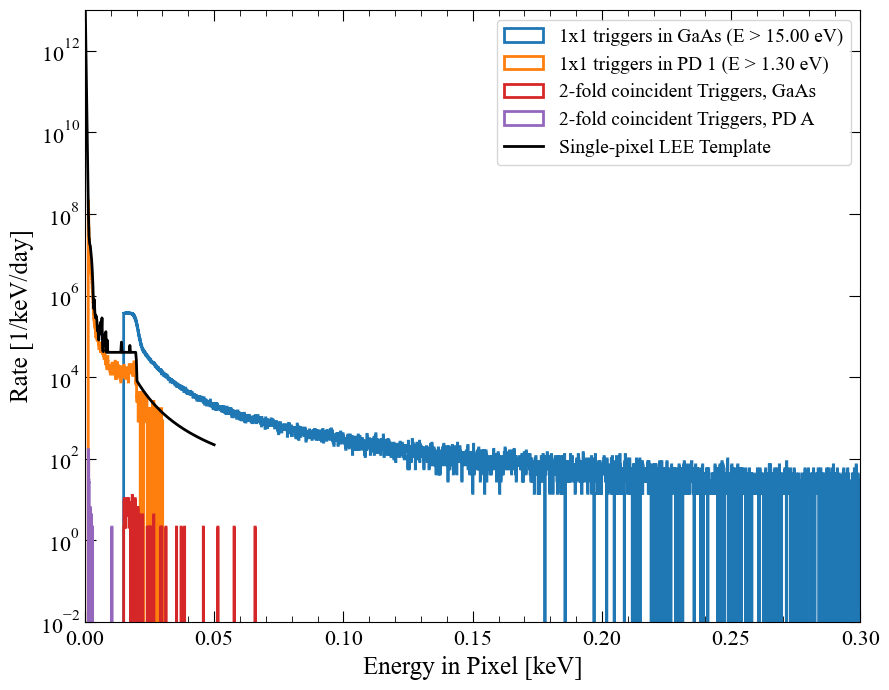

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
keV_bins = np.arange(0, 300, 0.1) * 1e-3 

E_th_PD = 1.3

####################
# 1-fold coincidence
####################

single_pixel = E0_full > E_th_GaAs
duration_days = eff_exposure_GaAs_hours / 24
ax.hist(E0_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C0', lw=2,
        label=f'1x1 triggers in GaAs (E > {E_th_GaAs:.2f} eV)')
hist_E_E0_single, bin_edges = np.histogram(E0_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_GaAs = sum(hist_E_E0_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in GaAs: {duration_days:.2f} days')

single_pixel = E1_full > E_th_PD
duration_days = eff_exposure_PD1_hours / 24
ax.hist(E1_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C1', lw=2,
        label=f'1x1 triggers in PD 1 (E > {E_th_PD:.2f} eV)')
hist_E_E1_single, bin_edges = np.histogram(E1_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_PD_A = sum(hist_E_E1_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in PD 1: {duration_days:.2f} days')

####################
# 2-fold coincidence
####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (delta_delta_full < 9)
detected_overall = np.copy(detected)
duration_days = eff_exposure_per_run_PD1_hours * eff_exposure_per_run_GaAs_hours / run_length_hours / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C3', lw=2,
        label='2-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C4', lw=2,
        label='2-fold coincident Triggers, PD A')

hist_E_2fold_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_2fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_2fold = sum(hist_E_2fold_GaAs * np.diff(bin_edges))

print(f'Effective 2-fold PD exposure: {duration_days:.2f} days')

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + f'LEE_2fold_PD_{E_th_PD:.1f}_GaAs_{E_th_GaAs:.1f}.txt',
           np.column_stack((E_save, hist_E_2fold_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')

# ####################
# # Wrapping up
# ####################


E_arr = np.linspace(0.1, 50, 200) * 1e-3
dRdE_arr = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_arr)
ax.plot(E_arr, dRdE_arr * 86400, color='k', label='Single-pixel LEE Template', lw=2)

ax.set_yscale('log')
ax.set_xlabel('Energy in Pixel [keV]')
ax.set_ylabel('Rate [1/keV/day]')
ax.set_ylim([1e-2, 1e13])
ax.set_xlim([0, 300e-3])

ax.legend(loc='upper right', fontsize=14)
fig.tight_layout()
fig.show()

print(f'\nRates [1/day]:')
print(f'2-fold in GaAs, with either PD: {R_coincident_2fold:.2e}')
print(f'Number of coincident events: {sum(detected):,}')

Effective 1-fold exposure in GaAs: 71.00 days
Effective 1-fold exposure in PD 1: 0.07 days
Effective 2-fold exposure: 112.92 days
Effective 3-fold exposure: 179.59 days

Rates [1/day]:
1-fold in GaAs: 1086
1-fold in PD 1: 113943
2-fold in GaAs, with either PD: 6.91e-01
3-fold in GaAs: 0.00e+00
3-fold in GaAs with Delta Chi2 < 9: 0.00e+00

Raw Numbers:
Number of detected events: 183,499
Number of events passing the 2-fold cut: 78
Number of events passing all cuts: 0


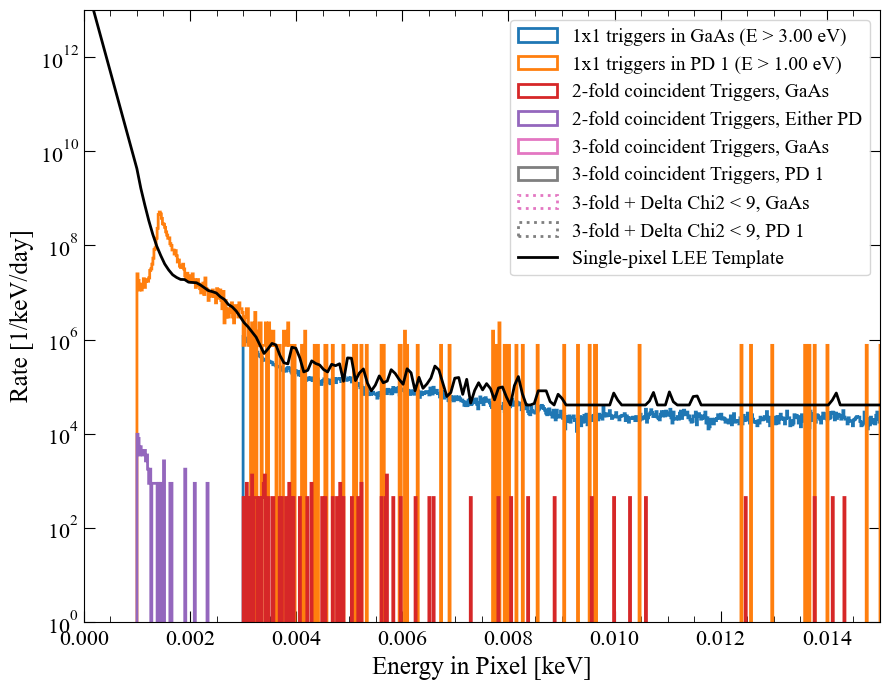

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
keV_bins = np.arange(0.1, 100, 0.02) * 1e-3

####################
# 1-fold coincidence
####################

single_pixel = E0_full > E_th_GaAs
duration_days = eff_exposure_GaAs_hours / 24
ax.hist(E0_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C0', lw=2,
        label=f'1x1 triggers in GaAs (E > {E_th_GaAs:.2f} eV)')
hist_E_E0_single, bin_edges = np.histogram(E0_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_GaAs = sum(hist_E_E0_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in GaAs: {duration_days:.2f} days')

single_pixel = E1_full > E_th_PD
duration_days = eff_exposure_PD1_hours / 24
ax.hist(E1_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C1', lw=2,
        label=f'1x1 triggers in PD 1 (E > {E_th_PD:.2f} eV)')
hist_E_E1_single, bin_edges = np.histogram(E1_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_PD_A = sum(hist_E_E1_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in PD 1: {duration_days:.2f} days')

# ####################
# # 2-fold coincidence
# ####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) + (E0_full > E_th_GaAs) * (E2_full > E_th_PD)
detected_A = (E0_full > E_th_GaAs) * (E1_full > E_th_PD)
detected_2fold = np.copy(detected)

duration_days = eff_exposure_per_run_GaAs_hours * eff_exposure_per_run_PD1_hours / run_length_hours / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C3', lw=2,
        label='2-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected_A]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected_A), 2/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C4', lw=2,
        label='2-fold coincident Triggers, Either PD')

hist_E_2fold_PD, bin_edges = np.histogram(E1_full[detected_A]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected_A), 2/np.diff(keV_bins)[0]/duration_days))
hist_E_2fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_2fold = sum(hist_E_2fold_GaAs * np.diff(bin_edges))

print(f'Effective 2-fold exposure: {duration_days:.2f} days')

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + 'background_spectrum_2fold.txt',
           np.column_stack((E_save, hist_E_2fold_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')


# ####################
# # 3-fold coincidence
# ####################

keV_bins = np.arange(0, 20, 0.03) * 1e-3  # Reduce the number of bins for 3-fold coincidence histogram
detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (E2_full > E_th_PD)
duration_days = eff_exposure_per_run_GaAs_hours * eff_exposure_per_run_PD1_hours**2 / run_length_hours**2 / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C6', lw=2,
        label='3-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C7', lw=2,
        label='3-fold coincident Triggers, PD 1')

hist_E_3fold_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_3fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_3fold = sum(hist_E_3fold_GaAs * np.diff(bin_edges))

print(f'Effective 3-fold exposure: {duration_days:.2f} days')

# ####################
# # Adding delta delta cut
# ####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (E2_full > E_th_PD) * (delta_delta_full < 9)
detected_overall = np.copy(detected)
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C6', lw=2, linestyle=':',
        label='3-fold + Delta Chi2 < 9, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C7', lw=2, linestyle=':',
        label='3-fold + Delta Chi2 < 9, PD 1')

hist_E_3fold_delta_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_3fold_delta_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_3fold_delta = sum(hist_E_3fold_delta_GaAs * np.diff(bin_edges))

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + 'background_spectrum_3fold.txt',
           np.column_stack((E_save, hist_E_3fold_delta_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')

# ####################
# # Wrapping up
# ####################


E_arr = np.linspace(0.1, 15, 200) * 1e-3
dRdE_arr = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_arr)
ax.plot(E_arr, dRdE_arr * 86400, color='k', label='Single-pixel LEE Template', lw=2)

ax.set_yscale('log')
ax.set_xlabel('Energy in Pixel [keV]')
ax.set_ylabel('Rate [1/keV/day]')
ax.set_ylim([1e0, 1e13])
ax.set_xlim([0, 15e-3])

ax.legend(loc='upper right', fontsize=14)
fig.tight_layout()
fig.show()

print(f'\nRates [1/day]:')
print(f'1-fold in GaAs: {R_single_GaAs:.0f}')
print(f'1-fold in PD 1: {R_single_PD_A:.0f}')
print(f'2-fold in GaAs, with either PD: {R_coincident_2fold:.2e}')
print(f'3-fold in GaAs: {R_coincident_3fold:.2e}')
print(f'3-fold in GaAs with Delta Chi2 < 9: {R_coincident_3fold_delta:.2e}')

print('\nRaw Numbers:')
print(f'Number of detected events: {len(E0_full):,}')
print(f'Number of events passing the 2-fold cut: {sum(detected_2fold):,}')
print(f'Number of events passing all cuts: {sum(detected_overall):,}')



In [ ]:

for E_th_PD in [1.0, 1.1, 1.2, 1.3]:
        for E_th_GaAs in [1.0, 1.5, 2.0, 2.5]:

                ######################
                # 3-fold coincidence
                ######################
                
                keV_bins = np.arange(0, 20, 0.03) * 1e-3  # Reduce the number of bins for 3-fold coincidence histogram
                duration_days = eff_exposure_per_run_GaAs_hours * eff_exposure_per_run_PD1_hours**2 / run_length_hours**2 / 24 * n_runs

                detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (E2_full > E_th_PD) * (delta_delta_full < 9)
                detected_overall = np.copy(detected)

                hist_E_3fold_delta_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                                weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
                R_coincident_3fold_delta = sum(hist_E_3fold_delta_GaAs * np.diff(bin_edges))

                # Export to a file
                E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
                np.savetxt(dirname + f'background_spectrum_3fold_PD_{E_th_PD:.1f}eV_GaAs_{E_th_GaAs:.1f}eV.txt',
                        np.column_stack((E_save, hist_E_3fold_delta_GaAs)),
                        header='Energy [keV]     dRdE GaAs [1/keV/day]',
                        fmt='%.4e')

                print(f'E_th_PD = {E_th_PD}, E_th_GaAs = {E_th_GaAs}: 3-fold in GaAs with Delta Chi2 < 9: {R_coincident_3fold_delta:.2e}')

print('')
for E_th_PD in [1.0, 1.1, 1.2, 1.3]:
        for E_th_GaAs in [1.0, 1.5, 2.0, 2.5]:
        
                ####################
                # 2-fold coincidence
                ####################

                detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) + (E0_full > E_th_GaAs) * (E2_full > E_th_PD)
                duration_days = eff_exposure_per_run_GaAs_hours * eff_exposure_per_run_PD1_hours / run_length_hours / 24 * n_runs
                hist_E_2fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                                weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
                R_coincident_2fold = sum(hist_E_2fold_GaAs * np.diff(bin_edges))

                # Export to a file
                E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
                np.savetxt(dirname + f'background_spectrum_2fold_PD_{E_th_PD:.1f}eV_GaAs_{E_th_GaAs:.1f}eV.txt',
                        np.column_stack((E_save, hist_E_2fold_GaAs)),
                        header='Energy [keV]     dRdE GaAs [1/keV/day]',
                        fmt='%.4e')

                print(f'E_th_PD = {E_th_PD}, E_th_GaAs = {E_th_GaAs}: 2-fold in GaAs with Delta Chi2 < 9: {R_coincident_2fold:.2e}')


E_th_PD = 1.0, E_th_GaAs = 1.0: 3-fold in GaAs with Delta Chi2 < 9: 2.01e-01
E_th_PD = 1.0, E_th_GaAs = 1.5: 3-fold in GaAs with Delta Chi2 < 9: 8.94e-02
E_th_PD = 1.0, E_th_GaAs = 2.0: 3-fold in GaAs with Delta Chi2 < 9: 2.73e-02
E_th_PD = 1.0, E_th_GaAs = 2.5: 3-fold in GaAs with Delta Chi2 < 9: 5.46e-03
E_th_PD = 1.1, E_th_GaAs = 1.0: 3-fold in GaAs with Delta Chi2 < 9: 5.61e-02
E_th_PD = 1.1, E_th_GaAs = 1.5: 3-fold in GaAs with Delta Chi2 < 9: 2.58e-02
E_th_PD = 1.1, E_th_GaAs = 2.0: 3-fold in GaAs with Delta Chi2 < 9: 8.94e-03
E_th_PD = 1.1, E_th_GaAs = 2.5: 3-fold in GaAs with Delta Chi2 < 9: 1.99e-03
E_th_PD = 1.2, E_th_GaAs = 1.0: 3-fold in GaAs with Delta Chi2 < 9: 1.89e-02
E_th_PD = 1.2, E_th_GaAs = 1.5: 3-fold in GaAs with Delta Chi2 < 9: 8.94e-03
E_th_PD = 1.2, E_th_GaAs = 2.0: 3-fold in GaAs with Delta Chi2 < 9: 3.48e-03
E_th_PD = 1.2, E_th_GaAs = 2.5: 3-fold in GaAs with Delta Chi2 < 9: 4.97e-04
E_th_PD = 1.3, E_th_GaAs = 1.0: 3-fold in GaAs with Delta Chi2 < 9: 4.97e-03